In [ ]:
# file: scripts/clustering_pipeline.py
# -*- coding: utf-8 -*-
"""
Clustering pipeline: Scanpy + Leiden (train 調參 -> 全體重跑)
- 強化 QC、整合、調參、穩定性與輸出規範
- 作業規範：輸出 cluster_membership.csv (1-indexed, 有表頭) 於 OUT_DIR
"""

import os
import math
import json
import warnings
from dataclasses import dataclass, asdict
from typing import List, Optional, Tuple, Dict

import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import adjusted_rand_score, v_measure_score, silhouette_score

warnings.filterwarnings("ignore")

# -------------------- Config --------------------
@dataclass
class ClustConfig:
    train_ad_path: str = "../train_data/train_adata.h5ad"
    test_ad_path: str = "../test_data/test_adata.h5ad"
    out_dir: str = "./outputs_clust"

    label_col: str = "highLevelType"   # train 標籤欄位
    batch_key: str = "Sample"          # 或 "Patient" 依資料

    n_top_hvg: int = 3000
    max_pcs: int = 50                  # PCA 上限，實際以解釋變異率或 min(n_genes, n_cells) 限制
    var_explained_target: float = 0.9  # 達標就截斷，避免過大
    neighbors_k: Optional[int] = None  # None -> 自動 sqrt(n_cells)
    umap_min_dist: float = 0.4

    use_harmony: bool = True           # 裝了 harmonypy 才會啟用；否則退化
    use_bbknn_if_no_harmony: bool = True

    res_grid: List[float] = None       # 若 None -> 預設網格
    leiden_repeats: int = 5            # 每個 resolution 多次重啟（取平均分數）
    random_state: int = 42

    min_cluster_size: int = 30         # 小群閾值（可選合併）
    merge_small_clusters: bool = False # 是否併小群
    verbose: bool = True

    def __post_init__(self):
        if self.res_grid is None:
            self.res_grid = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

# -------------------- Utils --------------------
def log(msg: str, v: bool = True):
    if v:
        print(msg)

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def set_seeds(seed: int):
    np.random.seed(seed)

def compute_pct_mt(adata: sc.AnnData) -> None:
    # why: 監控品質（對不同物種自動判斷前綴）
    vnames = adata.var_names.str.upper()
    if vnames.str.startswith("MT-").any():
        mt_mask = vnames.str.startswith("MT-")
    elif vnames.str.startswith("MT_").any():
        mt_mask = vnames.str.startswith("MT_")
    else:
        mt_mask = np.zeros(adata.n_vars, dtype=bool)
    adata.var["mt"] = mt_mask
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

def basic_qc(adata: sc.AnnData,
             min_genes: int = 200,
             min_cells: int = 3,
             max_mt_pct: Optional[float] = 20.0) -> None:
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)
    compute_pct_mt(adata)
    if max_mt_pct is not None and "pct_counts_mt" in adata.obs:
        adata._inplace_subset_obs(adata.obs["pct_counts_mt"] <= max_mt_pct)

def normalize_log1p(adata: sc.AnnData) -> None:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

def select_hvg(adata: sc.AnnData, n_top: int, batch_key: Optional[str]) -> None:
    if batch_key and batch_key in adata.obs:
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top, flavor="seurat_v3", batch_key=batch_key)
    else:
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top, flavor="seurat_v3")
    adata._inplace_subset_var(adata.var["highly_variable"].values)

def auto_n_pcs(adata: sc.AnnData, max_pcs: int, target: float) -> int:
    # 以 PCA 後的解釋變異率序列決定實際使用 pcs
    evr = np.array(adata.uns.get("pca", {}).get("variance_ratio", []))
    if evr.size == 0:
        return min(max_pcs, adata.obsm["X_pca"].shape[1])
    csum = evr.cumsum()
    k = int(np.searchsorted(csum, target) + 1)
    return int(max(10, min(k, max_pcs)))

def make_neighbors_k(n_cells: int, user_k: Optional[int]) -> int:
    if user_k is not None:
        return int(user_k)
    return int(max(5, min(30, round(math.sqrt(n_cells)))))

def integrate_embedding(adata: sc.AnnData, cfg: ClustConfig) -> str:
    """
    傳回可用於 neighbors 的 obsm key
    優先和聲 Harmony；沒裝則嘗試 BBKNN；否則回退 PCA
    """
    rep_key = "X_pca"
    if cfg.use_harmony:
        try:
            import harmonypy  # noqa: F401
            key = cfg.batch_key if cfg.batch_key in adata.obs else "set"
            sc.external.pp.harmony_integrate(adata, key)
            return "X_pca_harmony"
        except Exception:
            pass
    if cfg.use_bbknn_if_no_harmony:
        try:
            import bbknn  # noqa: F401
            key = cfg.batch_key if cfg.batch_key in adata.obs else "set"
            sc.external.pp.bbknn(adata, batch_key=key)
            # bbknn 已建圖，後續直接 umap/leiden 即可
            return rep_key
        except Exception:
            pass
    return rep_key

def run_leiden_once(adata: sc.AnnData, res: float, random_state: int, key: str = "leiden_tmp") -> None:
    sc.tl.leiden(adata, resolution=res, key_added=key, random_state=random_state)

def tune_leiden(
    adata_all: sc.AnnData,
    cfg: ClustConfig,
    train_mask: np.ndarray,
    has_label: bool
) -> Tuple[float, pd.DataFrame]:
    """
    調參：多 resolution × repeats，取平均分數挑最佳
    有標籤 -> 平均(ARI, V)
    無標籤 -> Silhouette (用整體 embedding；labels 來自 Leiden)
    """
    scores = []
    y_true = None
    if has_label:
        y_true = adata_all.obs.loc[train_mask, cfg.label_col].astype(str).values

    for res in cfg.res_grid:
        rep_key = "X_emb_for_sil"
        # 以 neighbors 所用表示作為 silhouette 的特徵（Harmony/BBKNN/PCA）
        if "X_pca_harmony" in adata_all.obsm:
            X_emb = adata_all.obsm["X_pca_harmony"]
        else:
            X_emb = adata_all.obsm.get("X_pca", None)
        if X_emb is not None:
            adata_all.obsm[rep_key] = X_emb

        ari_list, v_list, sil_list = [], [], []
        for r in range(cfg.leiden_repeats):
            key_tmp = f"leiden_{res}_rep{r}"
            run_leiden_once(adata_all, res=res, random_state=cfg.random_state + r, key=key_tmp)
            y_pred_tr = adata_all.obs.loc[train_mask, key_tmp].astype(str).values
            if has_label:
                ari = adjusted_rand_score(y_true, y_pred_tr)
                vm = v_measure_score(y_true, y_pred_tr)
                ari_list.append(ari)
                v_list.append(vm)
            else:
                try:
                    sil = silhouette_score(adata_all.obsm[rep_key][train_mask], y_pred_tr, metric="euclidean")
                except Exception:
                    sil = np.nan
                sil_list.append(sil)

        if has_label:
            ari_mean = float(np.nanmean(ari_list)) if ari_list else np.nan
            v_mean = float(np.nanmean(v_list)) if v_list else np.nan
            score = 0.5 * (ari_mean + v_mean)
            scores.append((res, ari_mean, v_mean, score))
        else:
            sil_mean = float(np.nanmean(sil_list)) if sil_list else np.nan
            scores.append((res, None, None, sil_mean))

    cols = ["resolution", "ARI", "V", "score"]
    tab = pd.DataFrame(scores, columns=cols)
    # 挑最大 score 的 resolution；若分數並列，取較小 res（較保守）
    tab_sorted = tab.sort_values(["score", "resolution"], ascending=[False, True]).reset_index(drop=True)
    best_res = float(tab_sorted.loc[0, "resolution"])
    return best_res, tab_sorted

def merge_tiny_clusters(
    adata: sc.AnnData,
    label_key: str,
    min_size: int,
    neighbors_key: str = "neighbors"
) -> None:
    """
    將小於 min_size 的群，以 KNN 多數表決併入相鄰大群。
    """
    sizes = adata.obs[label_key].value_counts()
    tiny = sizes[sizes < min_size].index.tolist()
    if len(tiny) == 0:
        return
    # 建鄰近表
    if neighbors_key not in adata.uns:
        sc.pp.neighbors(adata)
    knn = adata.obsp["connectivities"]
    labels = adata.obs[label_key].astype(str).values
    cat_to_id = {c: i for i, c in enumerate(sorted(adata.obs[label_key].astype(str).unique()))}
    labels_id = np.array([cat_to_id[c] for c in labels])

    # 迭代併入
    for cl in tiny:
        mask = adata.obs[label_key].astype(str) == cl
        idx = np.where(mask.values)[0]
        # 鄰接到的其他 cluster 投票
        neigh_weights = np.asarray(knn[idx, :].sum(axis=0)).ravel()
        neigh_weights[idx] = 0.0
        # 對每個 cluster 加總權重
        votes = {}
        for i, c in enumerate(labels):
            if i in idx:  # 跳過本群
                continue
            votes[c] = votes.get(c, 0.0) + neigh_weights[i]
        if not votes:
            continue
        target = max(votes.items(), key=lambda x: x[1])[0]
        adata.obs.loc[mask, label_key] = target

# -------------------- Main pipeline --------------------
def main(cfg: ClustConfig):
    set_seeds(cfg.random_state)
    ensure_dir(cfg.out_dir)

    log(f"[config]\n{json.dumps(asdict(cfg), indent=2)}", cfg.verbose)

    # 1) Load
    ad_tr = sc.read_h5ad(cfg.train_ad_path)
    ad_te = sc.read_h5ad(cfg.test_ad_path)

    has_label_train = (cfg.label_col in ad_tr.obs)

    # 2) Train: QC -> norm/log -> HVG -> scale -> PCA
    log("Step 2: QC/Normalize/HVG/PCA on TRAIN", cfg.verbose)
    basic_qc(ad_tr, min_genes=200, min_cells=3, max_mt_pct=20.0)
    normalize_log1p(ad_tr)
    select_hvg(ad_tr, n_top=cfg.n_top_hvg, batch_key=cfg.batch_key if cfg.batch_key in ad_tr.obs else None)
    sc.pp.scale(ad_tr, max_value=10)
    sc.tl.pca(ad_tr, n_comps=min(cfg.max_pcs, ad_tr.n_vars, ad_tr.n_obs), svd_solver="arpack")

    # 2b) Test: 對齊 train HVGs 後 norm/log；PCA 於合併後重做
    log("Step 2b: Apply preprocess to TEST (align to train HVGs)", cfg.verbose)
    shared = ad_tr.var_names.intersection(ad_te.var_names)
    ad_te = ad_te[:, shared].copy()
    basic_qc(ad_te, min_genes=0, min_cells=0, max_mt_pct=None)  # test 不硬砍；僅計算 qc 欄位
    normalize_log1p(ad_te)
    # 只保留 train 的 HVG
    ad_te = ad_te[:, ad_tr.var_names].copy()

    # 3) 合併 -> 共同 scale + PCA
    log("Step 3: Concatenate train+test and recompute scale+PCA", cfg.verbose)
    ad_all = ad_tr.concatenate(ad_te, join="inner", batch_key="set", batch_categories=["train", "test"])
    sc.pp.scale(ad_all, max_value=10)
    sc.tl.pca(ad_all, n_comps=min(cfg.max_pcs, ad_all.n_vars, ad_all.n_obs), svd_solver="arpack")

    # 擷取合適的 PC 數
    n_use = auto_n_pcs(ad_all, max_pcs=cfg.max_pcs, target=cfg.var_explained_target)
    ad_all.obsm["X_pca"] = ad_all.obsm["X_pca"][:, :n_use]
    if "pca" in ad_all.uns and "variance_ratio" in ad_all.uns["pca"]:
        ad_all.uns["pca"]["variance_ratio"] = ad_all.uns["pca"]["variance_ratio"][:n_use]

    # 4) 整合（Harmony 或 BBKNN 或單純 PCA）
    log("Step 4: Integration (Harmony/BBKNN/none)", cfg.verbose)
    rep_key = integrate_embedding(ad_all, cfg)

    # 5) Neighbors + UMAP
    k = make_neighbors_k(ad_all.n_obs, cfg.neighbors_k)
    log(f"Step 5: Neighbors/UMAP (k={k})", cfg.verbose)
    if "connectivities" not in ad_all.obsp:  # 若 bbknn 沒建，則建一次
        sc.pp.neighbors(ad_all, n_neighbors=k, use_rep=rep_key)
    sc.tl.umap(ad_all, min_dist=cfg.umap_min_dist, random_state=cfg.random_state)

    # 6) 在 train 上調參分群
    train_mask = (ad_all.obs["set"] == "train").values
    best_res, tuning_tab = tune_leiden(ad_all, cfg, train_mask, has_label_train)
    tuning_tab.to_csv(os.path.join(cfg.out_dir, "train_tuning_scores.csv"), index=False)
    log(f"Best resolution = {best_res}", cfg.verbose)

    # 7) 以最佳參數重跑 Leiden
    sc.tl.leiden(ad_all, resolution=best_res, key_added="leiden", random_state=cfg.random_state)

    # （可選）併小群
    if cfg.merge_small_clusters and cfg.min_cluster_size > 0:
        log("Merging tiny clusters...", cfg.verbose)
        merge_tiny_clusters(ad_all, label_key="leiden", min_size=cfg.min_cluster_size)

    # 8) 視覺化（可選保存）
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        if has_label_train:
            sc.pl.umap(ad_all[train_mask], color=[cfg.label_col], title="Train: Ground truth",
                       show=False, ax=ax[0])
        else:
            sc.pl.umap(ad_all[train_mask], color=["set"], title="Train subset",
                       show=False, ax=ax[0])
        sc.pl.umap(ad_all[train_mask], color=["leiden"], title=f"Train: Leiden (res={best_res})",
                   show=False, ax=ax[1])
        plt.tight_layout()
        plt.savefig(os.path.join(cfg.out_dir, "umap_train_gt_vs_leiden.png"), dpi=160)
        plt.close()

        sc.pl.umap(ad_all, color=["set", "leiden"], wspace=0.4, show=False)
        plt.savefig(os.path.join(cfg.out_dir, "umap_all_set_leiden.png"), dpi=160)
        plt.close()
    except Exception:
        pass

    # 9) 評估（只在 train 有標籤時）
    if has_label_train:
        y_true = ad_all.obs.loc[train_mask, cfg.label_col].astype(str).values
        y_pred = ad_all.obs.loc[train_mask, "leiden"].astype(str).values
        ari = adjusted_rand_score(y_true, y_pred)
        vm = v_measure_score(y_true, y_pred)
        log(f"[Final on TRAIN] res={best_res} | ARI={ari:.4f} | V={vm:.4f} | mean={(ari+vm)/2:.4f}", cfg.verbose)

        # 對映表（僅供分析）
        crosstab = pd.crosstab(ad_all.obs.loc[train_mask, "leiden"],
                               ad_all.obs.loc[train_mask, cfg.label_col])
        crosstab.to_csv(os.path.join(cfg.out_dir, "train_leiden_vs_truth.csv"))

    # 10) 匯出 test 的 cluster_membership.csv（1-indexed）
    test_mask = (ad_all.obs["set"] == "test").values
    clusters_test = ad_all.obs.loc[test_mask, "leiden"].astype(str)
    cats = pd.Categorical(clusters_test)
    clusters_int = pd.Series(cats.codes + 1, index=clusters_test.index, name="cluster")

    df_out = pd.DataFrame({
        "index": np.arange(clusters_int.shape[0]),
        "cluster": clusters_int.values
    })
    out_csv = os.path.join(cfg.out_dir, "cluster_membership.csv")
    df_out.to_csv(out_csv, index=False)
    log(f"[OK] wrote: {out_csv}", cfg.verbose)

    # 保存一些中繼資訊
    ad_all.write(os.path.join(cfg.out_dir, "adata_all_processed.h5ad"))

if __name__ == "__main__":
    cfg = ClustConfig()
    main(cfg)


In [2]:
# === Clustering pipeline: Scanpy + Leiden (train調參 → 全體重跑) ===
# 請先確保安裝 scanpy: pip install scanpy harmonypy
import os, warnings, numpy as np, pandas as pd, scanpy as sc
from sklearn.metrics import adjusted_rand_score, v_measure_score

warnings.filterwarnings("ignore")

# -------- Paths --------
TRAIN_AD_PATH = "../train_data/train_adata.h5ad"   # 有標籤 (obs['highLevelType'])
TEST_AD_PATH  = "../test_data/test_adata.h5ad"     # 無標籤
OUT_DIR       = "./outputs_clust"
os.makedirs(OUT_DIR, exist_ok=True)

# -------- Hyperparams you may tune --------
N_TOP_HVG        = 3000
N_PCS            = 50
RES_GRID         = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]
NEIGHBORS_K      = 15
MIN_CLUSTER_SIZE = 30          # 可用於後處理（選擇性）
BATCH_KEY        = "Sample"    # 或 "Patient"（看你的 obs 欄位）

# -------- 1) Load --------
ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)

# 確認標籤欄位
LABEL_COL = "highLevelType"
has_label_train = LABEL_COL in ad_tr.obs

# -------- 2) 基本 QC + Normalize + HVG + PCA（fit 在 train，apply 到 test）--------
def basic_preprocess_fit(adata: sc.AnnData, batch_key: str = None):
    # 常見 QC（可依需要調整/加上 mt% 過濾等）
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    # Normalize+log
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    # HVGs（seurat_v3 對 batch 魯棒）
    sc.pp.highly_variable_genes(
        adata, n_top_genes=N_TOP_HVG, flavor="seurat_v3",
        batch_key=batch_key if batch_key in adata.obs else None
    )
    hvg = adata.var["highly_variable"].values
    adata._inplace_subset_var(hvg)
    # Scale & PCA（scale 可能讓 UMAP/鄰近圖更穩）
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=N_PCS, svd_solver="arpack")
    return adata

def basic_preprocess_apply(adata: sc.AnnData, ref: sc.AnnData):
    # 用 ref 的基因交集，保持相同變量空間
    shared = ref.var_names.intersection(adata.var_names)
    adata = adata[:, shared].copy()
    # 同樣 normalize/log
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    # 只保留 ref HVGs
    adata = adata[:, ref.var_names].copy()
    # scale + PCA：用 ref 的均值/方差和 PCA 載荷？
    # scanpy 沒有直接「套用 PCA 模型」API；我們用聯合再 PCA 比較簡單（下面 3) 會 concat）
    return adata

# 先在 train fit
ad_tr = basic_preprocess_fit(ad_tr, batch_key=BATCH_KEY)
# test 先做基本 normalize/log，HVG 由「之後合併」一體做 PCA
ad_te = basic_preprocess_apply(ad_te, ad_tr)

# -------- 3) 合併 train+test 再做 neighbors/UMAP/Leiden（避免資料落差）--------
# 這裡我們用「train 的 HVGs 子集」對兩者取交集後 concatenate，再重做 scale + PCA（共同空間）
adata_all = ad_tr.concatenate(ad_te, join="inner", batch_key="set", batch_categories=["train","test"])
# 重新 scale+PCA（共同空間）
sc.pp.scale(adata_all, max_value=10)
sc.tl.pca(adata_all, n_comps=N_PCS, svd_solver="arpack")

# 選擇是否做簡單 batch 調整（可選）
# 建議：如果 batch effect 重，可以用 Harmony（需 harmonypy）：
try:
    import harmonypy
    sc.external.pp.harmony_integrate(adata_all, key=BATCH_KEY if BATCH_KEY in adata_all.obs else "set")
    rep_key = "X_pca_harmony"
except Exception:
    rep_key = "X_pca"  # 沒裝 harmonypy 就用原 PCA

# 建圖（鄰近圖/UMAP）
sc.pp.neighbors(adata_all, n_neighbors=NEIGHBORS_K, use_rep=rep_key)
sc.tl.umap(adata_all)

# -------- 4) 在 train 部分上選擇 best resolution（max (ARI+V)/2）--------
train_mask = (adata_all.obs["set"] == "train")
label_train = None
if has_label_train:
    # 將原始 train 標籤對齊到 adata_all（concatenate 自動保留 obs）
    label_train = adata_all.obs.loc[train_mask, LABEL_COL].astype(str).values

best_res, best_score = None, -np.inf
scores_log = []

for res in RES_GRID:
    sc.tl.leiden(adata_all, resolution=res, key_added=f"leiden_{res}")
    # 只用 train cells 計算分數
    if has_label_train:
        pred = adata_all.obs.loc[train_mask, f"leiden_{res}"].astype(str).values
        ari = adjusted_rand_score(label_train, pred)
        vm  = v_measure_score(label_train, pred)
        score = 0.5*(ari+vm)
        scores_log.append((res, ari, vm, score))
        if score > best_score:
            best_score, best_res = score, res
    else:
        # 若沒有 train 標籤，退而用群落模組度來挑（scanpy 沒有預設；此處用平均鄰居連結作 proxy）
        # 簡化：選中位數 cluster size 最合理的一個（這只是占位法）
        sizes = adata_all.obs[f"leiden_{res}"].value_counts().values
        score = -np.std(sizes)
        scores_log.append((res, None, None, score))
        if score > best_score:
            best_score, best_res = score, res

# 寫出調參表
tab = pd.DataFrame(scores_log, columns=["resolution","ARI","V","score"])
tab.to_csv(os.path.join(OUT_DIR, "train_tuning_scores.csv"), index=False)
print("Tuning summary:\n", tab)

# 用最佳 resolution 重新產生最終 cluster
sc.tl.leiden(adata_all, resolution=best_res, key_added="leiden")

# -------- 5) 視覺化（可選）--------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(10,4))
sc.pl.umap(adata_all[train_mask], color=[LABEL_COL], title="Train: ground-truth", show=False, ax=ax[0])
sc.pl.umap(adata_all[train_mask], color=["leiden"], title=f"Train: Leiden (res={best_res})", show=False, ax=ax[1])
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "umap_train_gt_vs_leiden.png"), dpi=160); plt.close()

sc.pl.umap(adata_all, color=["set","leiden"], wspace=0.4, show=False)
# plt.savefig(os.path.join(OUT_DIR, "umap_all_set_leiden.png"), dpi=160); plt.close()

# -------- 6) 評估（只在 train 有標籤時）--------
if has_label_train:
    pred_train = adata_all.obs.loc[train_mask, "leiden"].astype(str).values
    ari = adjusted_rand_score(label_train, pred_train)
    vm  = v_measure_score(label_train, pred_train)
    print(f"[Final on TRAIN] best_res={best_res} | ARI={ari:.4f} | V={vm:.4f} | mean={(ari+vm)/2:.4f}")

# -------- 7) 匯出 test 的 cluster_membership.csv（1-indexed）--------
test_mask = (adata_all.obs["set"] == "test")
clusters_test_str = adata_all.obs.loc[test_mask, "leiden"].astype(str)
# 轉為 1-indexed 整數編號：先做 string→category→codes，再 +1
cats = pd.Categorical(clusters_test_str)
clusters_test_int = pd.Series(cats.codes + 1, index=clusters_test_str.index, name="cluster")

df_out = pd.DataFrame({
    "index": np.arange(clusters_test_int.shape[0]),
    "cluster": clusters_test_int.values
})
# df_out.to_csv(os.path.join(OUT_DIR, "cluster_membership.csv"), index=False)
print(f"[OK] wrote: {os.path.join(OUT_DIR, 'cluster_membership.csv')}")

# （可選）也輸出 train 的對映表，看每個 Leiden 群對應到哪個主 cell type（僅供分析）
if has_label_train:
    crosstab = pd.crosstab(
        adata_all.obs.loc[train_mask, "leiden"],
        adata_all.obs.loc[train_mask, LABEL_COL]
    )
    # crosstab.to_csv(os.path.join(OUT_DIR, "train_leiden_vs_truth.csv"))
    print("Saved train_leiden_vs_truth.csv")

# -------- 8) 小貼士：如果想過濾太小的 cluster，可以做這段（非必要）--------
# sizes = adata_all.obs["leiden"].value_counts()
# small = sizes[sizes < MIN_CLUSTER_SIZE].index.tolist()
# if len(small) > 0:
#     # 把小群併到最近的大群（需要額外實作；交作業不必）
#     pass


2025-11-16 01:33:44,412 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-16 01:33:59,154 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-16 01:33:59,457 - harmonypy - INFO - Iteration 1 of 10
2025-11-16 01:34:20,668 - harmonypy - INFO - Iteration 2 of 10
2025-11-16 01:34:41,881 - harmonypy - INFO - Iteration 3 of 10
2025-11-16 01:35:03,777 - harmonypy - INFO - Converged after 3 iterations


ImportError: Please install the leiden algorithm: `conda install -c conda-forge leidenalg` or `pip3 install leidenalg`.

Tuning summary:
    resolution       ARI         V     score
0         0.2  0.781773  0.813650  0.797711
1         0.4  0.577259  0.744886  0.661072
2         0.6  0.446252  0.696373  0.571313
3         0.8  0.405152  0.684105  0.544629
4         1.0  0.361337  0.655946  0.508641
5         1.2  0.343297  0.647445  0.495371
6         1.5  0.325657  0.631420  0.478539
7         2.0  0.270070  0.600685  0.435377
[Final on TRAIN] best_res=0.2 | ARI=0.7818 | V=0.8136 | mean=0.7977
[OK] wrote: ./outputs_clust\cluster_membership.csv
Saved train_leiden_vs_truth.csv


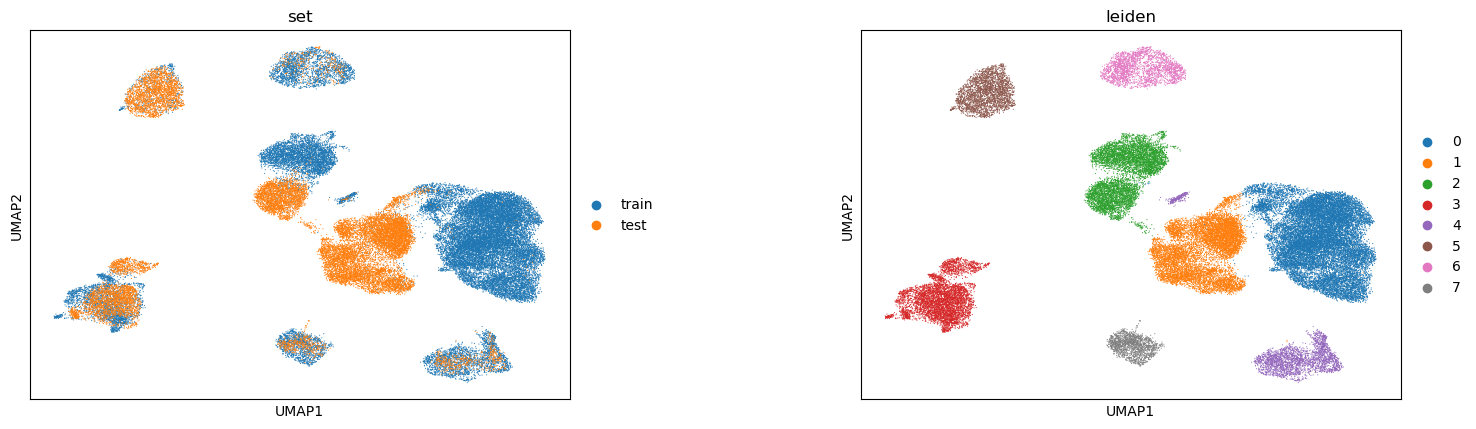

In [3]:

for res in RES_GRID:
    sc.tl.leiden(adata_all, resolution=res, key_added=f"leiden_{res}")
    # 只用 train cells 計算分數
    if has_label_train:
        pred = adata_all.obs.loc[train_mask, f"leiden_{res}"].astype(str).values
        ari = adjusted_rand_score(label_train, pred)
        vm  = v_measure_score(label_train, pred)
        score = 0.5*(ari+vm)
        scores_log.append((res, ari, vm, score))
        if score > best_score:
            best_score, best_res = score, res
    else:
        # 若沒有 train 標籤，退而用群落模組度來挑（scanpy 沒有預設；此處用平均鄰居連結作 proxy）
        # 簡化：選中位數 cluster size 最合理的一個（這只是占位法）
        sizes = adata_all.obs[f"leiden_{res}"].value_counts().values
        score = -np.std(sizes)
        scores_log.append((res, None, None, score))
        if score > best_score:
            best_score, best_res = score, res

# 寫出調參表
tab = pd.DataFrame(scores_log, columns=["resolution","ARI","V","score"])
tab.to_csv(os.path.join(OUT_DIR, "train_tuning_scores.csv"), index=False)
print("Tuning summary:\n", tab)

# 用最佳 resolution 重新產生最終 cluster
sc.tl.leiden(adata_all, resolution=best_res, key_added="leiden")

# -------- 5) 視覺化（可選）--------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(10,4))
sc.pl.umap(adata_all[train_mask], color=[LABEL_COL], title="Train: ground-truth", show=False, ax=ax[0])
sc.pl.umap(adata_all[train_mask], color=["leiden"], title=f"Train: Leiden (res={best_res})", show=False, ax=ax[1])
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "umap_train_gt_vs_leiden.png"), dpi=160); plt.close()

sc.pl.umap(adata_all, color=["set","leiden"], wspace=0.4, show=False)
# plt.savefig(os.path.join(OUT_DIR, "umap_all_set_leiden.png"), dpi=160); plt.close()

# -------- 6) 評估（只在 train 有標籤時）--------
if has_label_train:
    pred_train = adata_all.obs.loc[train_mask, "leiden"].astype(str).values
    ari = adjusted_rand_score(label_train, pred_train)
    vm  = v_measure_score(label_train, pred_train)
    print(f"[Final on TRAIN] best_res={best_res} | ARI={ari:.4f} | V={vm:.4f} | mean={(ari+vm)/2:.4f}")

# -------- 7) 匯出 test 的 cluster_membership.csv（1-indexed）--------
test_mask = (adata_all.obs["set"] == "test")
clusters_test_str = adata_all.obs.loc[test_mask, "leiden"].astype(str)
# 轉為 1-indexed 整數編號：先做 string→category→codes，再 +1
cats = pd.Categorical(clusters_test_str)
clusters_test_int = pd.Series(cats.codes + 1, index=clusters_test_str.index, name="cluster")

df_out = pd.DataFrame({
    "index": np.arange(clusters_test_int.shape[0]),
    "cluster": clusters_test_int.values
})
# df_out.to_csv(os.path.join(OUT_DIR, "cluster_membership.csv"), index=False)
print(f"[OK] wrote: {os.path.join(OUT_DIR, 'cluster_membership.csv')}")

# （可選）也輸出 train 的對映表，看每個 Leiden 群對應到哪個主 cell type（僅供分析）
if has_label_train:
    crosstab = pd.crosstab(
        adata_all.obs.loc[train_mask, "leiden"],
        adata_all.obs.loc[train_mask, LABEL_COL]
    )
    # crosstab.to_csv(os.path.join(OUT_DIR, "train_leiden_vs_truth.csv"))
    print("Saved train_leiden_vs_truth.csv")

# -------- 8) 小貼士：如果想過濾太小的 cluster，可以做這段（非必要）--------
# sizes = adata_all.obs["leiden"].value_counts()
# small = sizes[sizes < MIN_CLUSTER_SIZE].index.tolist()
# if len(small) > 0:
#     # 把小群併到最近的大群（需要額外實作；交作業不必）
#     pass


In [8]:
# === Train/Val split + y inspection for your clustering pipeline ===
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import adjusted_rand_score, v_measure_score

LABEL_COL = "highLevelType"  # 你的真值欄位
RANDOM_STATE = 42
VAL_SIZE = 0.2               # 20% 做 validation

# 1) 基於 "train cells" 建立 train/val（分層於 label）
train_mask_all = (adata_all.obs["set"] == "train").values
y_all = adata_all.obs.loc[train_mask_all, LABEL_COL].astype(str).values

idx_all = np.where(train_mask_all)[0]
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
tr_idx_sub, va_idx_sub = next(sss.split(idx_all, y_all))

# 轉回到 adata_all 的布林 mask
train_sub_mask = np.zeros(adata_all.n_obs, dtype=bool)
val_sub_mask   = np.zeros(adata_all.n_obs, dtype=bool)
train_sub_mask[idx_all[tr_idx_sub]] = True
val_sub_mask[idx_all[va_idx_sub]]   = True


In [9]:
y_all

array(['T', 'T', 'T', ..., 'T', 'T', 'T'], shape=(32374,), dtype=object)

In [10]:
# === Train/Val split + y inspection for your clustering pipeline ===
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import adjusted_rand_score, v_measure_score

LABEL_COL = "highLevelType"  # 你的真值欄位
RANDOM_STATE = 42
VAL_SIZE = 0.2               # 20% 做 validation

# 1) 基於 "train cells" 建立 train/val（分層於 label）
train_mask_all = (adata_all.obs["set"] == "train").values
y_all = adata_all.obs.loc[train_mask_all, LABEL_COL].astype(str).values

idx_all = np.where(train_mask_all)[0]
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
tr_idx_sub, va_idx_sub = next(sss.split(idx_all, y_all))

# 轉回到 adata_all 的布林 mask
train_sub_mask = np.zeros(adata_all.n_obs, dtype=bool)
val_sub_mask   = np.zeros(adata_all.n_obs, dtype=bool)
train_sub_mask[idx_all[tr_idx_sub]] = True
val_sub_mask[idx_all[va_idx_sub]]   = True

# 2) 觀察 y（ground truth）
y_true_train = adata_all.obs.loc[train_sub_mask, LABEL_COL].astype(str).values
y_true_val   = adata_all.obs.loc[val_sub_mask, LABEL_COL].astype(str).values

print("=== Split sizes ===")
print(f"train_sub cells = {train_sub_mask.sum()} | val_sub cells = {val_sub_mask.sum()}")

print("\n=== Label distribution (train_sub) ===")
print(pd.Series(y_true_train).value_counts().sort_index())

print("\n=== Label distribution (val_sub) ===")
print(pd.Series(y_true_val).value_counts().sort_index())

print("\n=== y_true_train (head 10) ===")
print(y_true_train[:10])

print("\n=== y_true_val (head 10) ===")
print(y_true_val[:10])

# 也可落檔供檢查
pd.Series(y_true_train, name="y_true_train").to_csv(os.path.join(OUT_DIR, "y_true_train.csv"), index=False)
pd.Series(y_true_val,   name="y_true_val").to_csv(os.path.join(OUT_DIR, "y_true_val.csv"),   index=False)

# 3) 以 val_sub 挑最佳 resolution（仍可同時計算 train_sub 分數供參考）
best_res, best_score = None, -np.inf
rows = []
for res in RES_GRID:
    sc.tl.leiden(adata_all, resolution=res, key_added=f"leiden_{res}", random_state=RANDOM_STATE)
    pred_train = adata_all.obs.loc[train_sub_mask, f"leiden_{res}"].astype(str).values
    pred_val   = adata_all.obs.loc[val_sub_mask,   f"leiden_{res}"].astype(str).values

    ari_tr = adjusted_rand_score(y_true_train, pred_train)
    vm_tr  = v_measure_score(y_true_train, pred_train)
    score_tr = 0.5*(ari_tr + vm_tr)

    ari_va = adjusted_rand_score(y_true_val, pred_val)
    vm_va  = v_measure_score(y_true_val, pred_val)
    score_va = 0.5*(ari_va + vm_va)

    rows.append((res, ari_tr, vm_tr, score_tr, ari_va, vm_va, score_va))
    if score_va > best_score:
        best_score, best_res = score_va, res
print(best_score)
tab = pd.DataFrame(rows, columns=["resolution","ARI_train","V_train","score_train",
                                  "ARI_val","V_val","score_val"])
# tab.to_csv(os.path.join(OUT_DIR, "trainval_tuning_scores.csv"), index=False)
print("\n=== Tuning (train/val) ===")
print(tab)

print(f"\n[Chosen by VAL] best_res={best_res} | best_val_mean={best_score:.4f}")

# 4) 用最佳 res 重新產生最終 cluster（在全部資料上）
sc.tl.leiden(adata_all, resolution=best_res, key_added="leiden", random_state=RANDOM_STATE)

# 5) 最終在 train_sub / val_sub 上回報一次
pred_train_final = adata_all.obs.loc[train_sub_mask, "leiden"].astype(str).values
pred_val_final   = adata_all.obs.loc[val_sub_mask,   "leiden"].astype(str).values

ari_tr = adjusted_rand_score(y_true_train, pred_train_final)
vm_tr  = v_measure_score(y_true_train, pred_train_final)
ari_va = adjusted_rand_score(y_true_val,   pred_val_final)
vm_va  = v_measure_score(y_true_val,   pred_val_final)

print(f"\n[Final (train_sub)] ARI={ari_tr:.4f} | V={vm_tr:.4f} | mean={(ari_tr+vm_tr)/2:.4f}")
print(f"[Final (val_sub)]   ARI={ari_va:.4f} | V={vm_va:.4f} | mean={(ari_va+vm_va)/2:.4f}")


=== Split sizes ===
train_sub cells = 25899 | val_sub cells = 6475

=== Label distribution (train_sub) ===
B                 3389
Endothelial        479
Fibroblast        2081
Mast               890
Myeloid           1989
Myofibroblast      575
NK                1529
Plasmablast       1626
T                13341
Name: count, dtype: int64

=== Label distribution (val_sub) ===
B                 847
Endothelial       120
Fibroblast        521
Mast              222
Myeloid           498
Myofibroblast     144
NK                382
Plasmablast       406
T                3335
Name: count, dtype: int64

=== y_true_train (head 10) ===
['T' 'T' 'B' 'T' 'T' 'Plasmablast' 'T' 'T' 'T' 'T']

=== y_true_val (head 10) ===
['T' 'Plasmablast' 'B' 'T' 'T' 'Mast' 'T' 'T' 'B' 'Plasmablast']
0.825728433683848

=== Tuning (train/val) ===
   resolution  ARI_train   V_train  score_train   ARI_val     V_val  score_val
0         0.2   0.832868  0.817947     0.825407  0.830660  0.820797   0.825728
1         0.4  

In [17]:
# --- fixed: make_counts_dataframe (uses .toarray() instead of .A) ---
from __future__ import annotations
from typing import Tuple
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

LABEL_COL = "highLevelType"  # 你的 cell type 欄位

def _looks_integer_counts(x_small: np.ndarray, tol: float = 1e-9) -> bool:
    x = np.asarray(x_small).ravel()
    if x.size == 0 or (x < -tol).any():
        return False
    return (np.abs(x - np.round(x)) <= tol).all()

def detect_counts_matrix(adata: sc.AnnData) -> Tuple[sparse.spmatrix | np.ndarray, pd.Index, str]:
    """優先：layers['counts'] → raw.X → X(像整數)。回傳 (mat, gene_index, source_tag)"""
    if hasattr(adata, "layers") and "counts" in adata.layers:
        return adata.layers["counts"], adata.var_names, 'layers["counts"]'
    if adata.raw is not None:
        return adata.raw.X, adata.raw.var_names, "raw.X"
    # fallback: probe .X 是否像整數
    probe = adata.X[: min(100, adata.n_obs), : min(100, adata.n_vars)]
    probe = probe.toarray() if sparse.issparse(probe) else np.asarray(probe)
    if _looks_integer_counts(probe):
        return adata.X, adata.var_names, "X (integer-like fallback)"
    raise ValueError("No raw counts in layers['counts']/raw.X，且 .X 也不像整數 counts。")

def ensure_pct_counts_mt(adata: sc.AnnData) -> None:
    if "pct_counts_mt" in adata.obs:
        return
    vnames = adata.var_names.str.upper()
    if vnames.str.startswith("MT-").any():
        adata.var["mt"] = vnames.str.startswith("MT-")
    elif vnames.str.startswith("MT_").any():
        adata.var["mt"] = vnames.str.startswith("MT_")
    else:
        adata.var["mt"] = False
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

def make_counts_dataframe(
    adata: sc.AnnData,
    label_col: str = LABEL_COL,
    use_sparse: bool = True
) -> pd.DataFrame:
    """
    產生：cells × genes 的 counts DataFrame，左側附加：
      - cell_type: 來自 obs[label_col]，缺者 NA
      - pct_counts_mt: 來自 obs['pct_counts_mt']（若無則自動計算）
    預設回傳 pandas 稀疏 DataFrame；use_sparse=False 產出 dense（大心）。
    """
    # 1) counts 來源
    mat, gene_idx, src = detect_counts_matrix(adata)

    # 2) 轉成 DataFrame（盡可能 sparse）
    if use_sparse:
        if not sparse.issparse(mat):
            mat = sparse.csr_matrix(mat)
        df_counts = pd.DataFrame.sparse.from_spmatrix(
            mat, index=adata.obs_names.copy(), columns=pd.Index(gene_idx, name="gene")
        )
    else:
        arr = mat.toarray() if sparse.issparse(mat) else np.asarray(mat)
        df_counts = pd.DataFrame(arr, index=adata.obs_names.copy(), columns=pd.Index(gene_idx, name="gene"))

    # 3) 加上 metadata 欄位
    ensure_pct_counts_mt(adata)
    cell_type = adata.obs[label_col].astype("string") if label_col in adata.obs else pd.Series(index=adata.obs_names, dtype="string")
    pct_mt = pd.to_numeric(adata.obs.get("pct_counts_mt", pd.Series(index=adata.obs_names, dtype=float)), errors="coerce")

    df_counts.insert(0, "pct_counts_mt", pct_mt)
    df_counts.insert(0, "cell_type", cell_type)

    df_counts.attrs["counts_source"] = src
    return df_counts

# --- usage ---
ad = sc.read_h5ad("../train_data/train_adata.h5ad")
df = make_counts_dataframe(ad, label_col="highLevelType", use_sparse=True)
print(df.shape, "counts source:", df.attrs.get("counts_source"))
# df.to_parquet("outputs_clust/all_cells_all_genes_counts.parquet")  # 建議
# # 或 CSV（很大）：df.to_csv("outputs_clust/all_cells_all_genes_counts.csv")


(32374, 7727) counts source: X (integer-like fallback)


In [18]:
df

gene,cell_type,pct_counts_mt,NOC2L,HES4,ISG15,TNFRSF18,TNFRSF4,SDF4,B3GALT6,UBE2J2,...,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,SELE,SOX17,CCL14
AAACCCAAGGAGACCT-1_1,T,6.076067,0,0,1.0,0,0,0,0,0,...,14.0,15.0,0,14.0,1.0,0,9.0,0,0,0
AAACCCAGTAGACAGC-1_1,T,3.380282,0,0,0,1.0,0,0,1.0,0,...,11.0,10.0,0,17.0,4.0,0,6.0,0,0,0
AAACCCAGTAGATCGG-1_1,T,4.365278,0,0,1.0,0,0,0,0,0,...,5.0,12.0,0,10.0,3.0,0,7.0,0,0,0
AAACCCAGTATCACCA-1_1,B,6.474150,0,0,0,0,0,1.0,0,0,...,12.0,11.0,1.0,25.0,4.0,0,15.0,0,0,0
AAACCCAGTTGGAGGT-1_1,T,4.429861,0,0,3.0,2.0,3.0,1.0,0,0,...,8.0,12.0,1.0,13.0,3.0,0,21.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTCTAGGCC-1_8,T,5.465523,0,0,0,0,0,0,0,0,...,16.0,29.0,1.0,5.0,3.0,1.0,21.0,0,0,0
TTTGTTGGTTCCTAAG-1_8,Myeloid,4.384960,0,0,0,0,1.0,2.0,0,1.0,...,49.0,48.0,3.0,39.0,10.0,1.0,22.0,0,0,0
TTTGTTGTCAAGGAGC-1_8,T,2.935421,0,0,0,3.0,2.0,1.0,0,0,...,8.0,10.0,2.0,7.0,1.0,0,1.0,0,0,0
TTTGTTGTCTAACGGT-1_8,T,6.699817,0,0,0,1.0,0,0,0,0,...,35.0,42.0,0,23.0,7.0,1.0,30.0,0,0,0


In [ ]:
# file: scripts/marker_scoring_from_df.py
# -*- coding: utf-8 -*-
from __future__ import annotations
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, f1_score, classification_report

# ------- core helpers -------
def _extract_gene_matrix(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    # why: 你的 df 前兩欄是 meta；其餘為基因
    meta_cols = [c for c in ["cell_type", "pct_counts_mt"] if c in df.columns]
    gene_cols = [c for c in df.columns if c not in meta_cols]
    X = df[gene_cols].copy()
    return X, gene_cols

def _cpm_log1p(X: pd.DataFrame) -> pd.DataFrame:
    lib = X.sum(axis=1).replace(0.0, 1.0)  # 防 0
    return np.log1p(X.div(lib, axis=0) * 1e4)

def _zscore_cols(X: pd.DataFrame) -> pd.DataFrame:
    # why: 讓不同基因分布可比
    mu = X.mean(axis=0)
    sd = X.std(axis=0).replace(0.0, 1.0)
    return (X - mu) / sd

def score_by_markers(
    df: pd.DataFrame,
    marker_dict: Dict[str, List[str]],
    use_zscore: bool = True,
    unknown_threshold: Optional[float] = None
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    以 marker 基因對每個 cell 類別打分（均值），回傳 (scores_df, y_pred)。
    - df: cells×genes 的表（前含 cell_type/pct_counts_mt 亦可）
    - marker_dict: {"T":[...], "B":[...], ...}
    - use_zscore: True -> 用 Z 分數的均值；False -> 用 logCPM 的均值
    - unknown_threshold: 若 max 分數 < 閾值 -> 預測 'UNK'（可選）
    """
    X_counts, gene_cols = _extract_gene_matrix(df)
    X_logcpm = _cpm_log1p(X_counts)
    X_feat = _zscore_cols(X_logcpm) if use_zscore else X_logcpm

    scores = {}
    for ct, genes in marker_dict.items():
        g = [g for g in genes if g in gene_cols]
        if len(g) == 0:
            # 沒有重疊 marker，給 NaN 分數
            scores[ct] = pd.Series(np.nan, index=X_feat.index)
            continue
        scores[ct] = X_feat[g].mean(axis=1)  # 簡單均值打分

    scores_df = pd.DataFrame(scores, index=X_feat.index)

    # 預測：取 argmax；可選閾值標 UNK
    y_pred = scores_df.idxmax(axis=1).astype("string")
    if unknown_threshold is not None:
        max_val = scores_df.max(axis=1)
        y_pred = y_pred.mask(max_val < unknown_threshold, "UNK")

    return scores_df, y_pred

def evaluate_if_ground_truth(
    df: pd.DataFrame,
    y_pred: pd.Series,
    label_col: str = "cell_type"
) -> pd.DataFrame:
    """
    若 df 內含真值，回傳簡易評估表（ARI、macro-F1）與列印分類報告。
    """
    if label_col not in df.columns:
        return pd.DataFrame({"metric": ["note"], "value": ["no ground truth"]})
    y_true = df[label_col].astype("string")
    # 過濾掉 y_true 里的 NA
    mask = y_true.notna()
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    ari = float(adjusted_rand_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))

    print("\n[Classification report]\n",
          classification_report(y_true, y_pred, zero_division=0))
    return pd.DataFrame({"metric": ["ARI", "macroF1"], "value": [ari, macro_f1]})

# ------- Example usage -------
# 假設你已有 df（make_counts_dataframe 回傳的那個）
# 準備一個 marker_dict（請用你自己的 marker 列表替換）
marker_dict = {
    "T": ["CD3D","CD3E","TRAC","CD2","IL7R"],
    "B": ["MS4A1","CD79A","CD74","CD19","BANK1"],
    "NK": ["NKG7","GNLY","PRF1","GZMB","KLRD1"],
    "Myeloid": ["LYZ","S100A8","S100A9","CTSS","LST1"],
    "Endothelial": ["PECAM1","VWF","KDR","KLF2","CLDN5"],
    "Fibroblast": ["COL1A1","COL1A2","DCN","LUM","COL3A1"],
    "Myofibroblast": ["TAGLN","ACTA2","MYL9","TAGLN2","CNN1"],
    "Plasmablast": ["MZB1","XBP1","PRDM1","JCHAIN","DERL3"],
    "Mast": ["TPSAB1","CPA3","KIT","MS4A2","HDC"],
}

scores_df, y_pred = score_by_markers(df, marker_dict, use_zscore=True, unknown_threshold=None)
metrics = evaluate_if_ground_truth(df, y_pred, label_col="cell_type")
print(metrics)

# # 保存
# scores_df.to_csv("outputs_clust/marker_scores_per_cell.csv")
# pd.DataFrame({"pred": y_pred}).to_csv("outputs_clust/marker_pred_labels.csv")


In [2]:
# %% [markdown]
# # Combined-Embedding → LightGBM (early stopping) → Clustering (Train/Val separated)
# - Embedding：**Train + Test** 先合併，再產生各種整合表徵（scVI / Scanorama / Harmony / FastMNN；能跑就跑）
# - 分類：LightGBM（GroupKFold 按病人）+ Early Stopping
# - 分群：Train / Val 分開建圖+Leiden，避免圖洩漏
# - 輸出到 ./outputs_integrate_cls_nb2

# %%
# =========================
# 0) 集中 Import 所有模型/工具
# =========================
import os, json, warnings
import numpy as np
import pandas as pd
import scanpy as sc

# sklearn
from sklearn.model_selection import GroupKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, adjusted_rand_score, v_measure_score

# 視覺（可選）
import matplotlib.pyplot as plt

# LightGBM（分類）
try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception as e:
    HAS_LGB = False
    print("[Warn] lightgbm not available:", e)

# scVI（深度整合）
try:
    import scvi
    HAS_SCVI = True
except Exception as e:
    HAS_SCVI = False
    print("[Info] scvi-tools not available:", e)

# Harmony
try:
    import harmonypy  # noqa
    HAS_HARMONY = True
except Exception as e:
    HAS_HARMONY = False
    print("[Info] harmonypy not available:", e)

# Scanorama
try:
    import scanpy.external as sce  # scanorama via scanpy.external
    HAS_SCANORAMA = True
except Exception as e:
    HAS_SCANORAMA = False
    print("[Info] scanpy.external not available:", e)

# FastMNN / mnnpy
try:
    import mnnpy
    HAS_MNN = True
except Exception as e:
    HAS_MNN = False
    print("[Info] mnnpy not available:", e)

warnings.filterwarnings("ignore")


# %%
# =========================
# 1) Config
# =========================
TRAIN_AD_PATH = "../train_data/train_adata.h5ad"
TEST_AD_PATH  = "../test_data/test_adata.h5ad"
OUT_DIR       = "./outputs_integrate_cls_nb2"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_COL     = "highLevelType"
PATIENT_COL   = "Patient"
SAMPLE_COL    = "Sample"
CHEMO_COL     = "chemo_status"   # 'pre'/'post'（若無將補 NA）
BATCH_KEY_TMP = "_batchkey"      # 合併病人×化療狀態

N_TOP_HVG     = 3000
MAX_PCS       = 50
SCVI_LATENT   = 30
SCVI_EPOCHS   = 200
RANDOM_STATE  = 42
N_SPLITS      = 5

NEIGHBORS_K   = 15
RES_GRID      = [0.2, 0.4, 0.6, 0.8, 1.0]

# LightGBM + Early Stopping
LGB_PARAMS = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=30,
    n_estimators=2000,          # 大一點，交由 early stopping 決定停止點
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
EARLY_STOP_ROUNDS = 50
EVAL_METRIC       = "multi_logloss"


# %%
# =========================
# 2) Load
# =========================
ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)

if LABEL_COL not in ad_tr.obs:
    raise ValueError(f"Missing label column '{LABEL_COL}' in train AnnData.obs")

print(f"TRAIN: cells={ad_tr.n_obs:,}, genes={ad_tr.n_vars:,}")
print(f"TEST : cells={ad_te.n_obs:,}, genes={ad_te.n_vars:,}")


# %%
# =========================
# 3) Preprocess
# - Train: QC→normalize→log1p→HVG(seurat_v3)
# - Test : 對齊 Train HVGs 並 normalize/log1p
# =========================
# Train
sc.pp.filter_cells(ad_tr, min_genes=200)
sc.pp.filter_genes(ad_tr, min_cells=3)
vup = ad_tr.var_names.str.upper()
ad_tr.var["mt"] = vup.str.startswith("MT-") | vup.str.startswith("MT_")
sc.pp.calculate_qc_metrics(ad_tr, qc_vars=["mt"], inplace=True)
sc.pp.normalize_total(ad_tr, target_sum=1e4)
sc.pp.log1p(ad_tr)
batch_key_for_hvg = PATIENT_COL if (PATIENT_COL in ad_tr.obs) else None
if batch_key_for_hvg:
    sc.pp.highly_variable_genes(ad_tr, n_top_genes=N_TOP_HVG, flavor="seurat_v3", batch_key=batch_key_for_hvg)
else:
    sc.pp.highly_variable_genes(ad_tr, n_top_genes=N_TOP_HVG, flavor="seurat_v3")
ad_tr._inplace_subset_var(ad_tr.var["highly_variable"].values)

# Test 對齊
shared = ad_tr.var_names.intersection(ad_te.var_names)
ad_te = ad_te[:, shared].copy()
sc.pp.normalize_total(ad_te, target_sum=1e4); sc.pp.log1p(ad_te)
ad_te = ad_te[:, ad_tr.var_names].copy()

print("After HVG alignment:")
print(f"TRAIN HVGs: {ad_tr.n_vars}, TEST aligned genes: {ad_te.n_vars}")


# %%
# =========================
# 4) **重點**：先合併 TRAIN + TEST，再做 EMBEDDING
#    （避免分別做表徵導致空間不一致）
# =========================
adata_all = ad_tr.concatenate(ad_te, join="inner", batch_key="set", batch_categories=["train","test"])

# 建 batch key = Patient|chemo（若欄位不存在則補 NA）
def _col_or_default(a, col, default):
    return (a.obs[col].astype(str) if col in a.obs else pd.Series([default]*a.n_obs, index=a.obs_names))
pat   = _col_or_default(adata_all, PATIENT_COL, "NApat")
chemo = _col_or_default(adata_all, CHEMO_COL, "NAchemo")
adata_all.obs[BATCH_KEY_TMP] = (pat + "|" + chemo).astype("category")
print("Batch key example:", adata_all.obs[BATCH_KEY_TMP].astype(str).value_counts().head())


# %%
# =========================
# 5) 產生多種 EMBEDDING（能跑就跑）
#    依序：scVI → Scanorama → Harmony-on-PCA(或PCA) → FastMNN
# =========================
rep_keys = {}

# 5.1 scVI（需要 counts；若沒有 layers['counts']/raw.X 則跳過）
if HAS_SCVI:
    try:
        if "counts" in adata_all.layers:
            scvi.model.SCVI.setup_anndata(adata_all, layer="counts", batch_key=BATCH_KEY_TMP)
        elif adata_all.raw is not None:
            adata_all.layers["_tmp_raw"] = adata_all.raw.X.copy()
            scvi.model.SCVI.setup_anndata(adata_all, layer="_tmp_raw", batch_key=BATCH_KEY_TMP)
        else:
            raise RuntimeError("No raw counts/layers['counts'] for scVI.")
        scvi.settings.seed = RANDOM_STATE
        mdl = scvi.model.SCVI(adata_all, n_latent=SCVI_LATENT, gene_likelihood="nb", seed=RANDOM_STATE)
        mdl.train(max_epochs=SCVI_EPOCHS, plan_kwargs={"lr": 1e-3})
        adata_all.obsm["X_scVI"] = mdl.get_latent_representation()
        if "_tmp_raw" in adata_all.layers: del adata_all.layers["_tmp_raw"]
        rep_keys["scVI"] = "X_scVI"
        print("[OK] scVI → X_scVI")
    except Exception as e:
        print("[Skip] scVI:", e)

# 5.2 Scanorama
if HAS_SCANORAMA:
    try:
        sce.pp.scanorama_integrate(adata_all, key=BATCH_KEY_TMP)  # adds X_scanorama
        rep_keys["Scanorama"] = "X_scanorama"
        print("[OK] Scanorama → X_scanorama")
    except Exception as e:
        print("[Skip] Scanorama:", e)

# 5.3 Harmony on PCA（若缺 harmonypy 則回退 PCA）
try:
    sc.pp.scale(adata_all, max_value=10)
    sc.tl.pca(adata_all, n_comps=min(MAX_PCS, adata_all.n_vars, adata_all.n_obs), svd_solver="arpack")
    if HAS_HARMONY:
        sc.external.pp.harmony_integrate(adata_all, key=BATCH_KEY_TMP)
        rep_keys["Harmony/PCA"] = "X_pca_harmony"
        print("[OK] Harmony → X_pca_harmony")
    else:
        rep_keys["Harmony/PCA"] = "X_pca"
        print("[Fallback] Harmony unavailable → use X_pca")
except Exception as e:
    print("[Warn] PCA/Harmony failed:", e)

# 5.4 FastMNN
if HAS_MNN:
    try:
        batches = adata_all.obs[BATCH_KEY_TMP].cat.categories
        ad_list = [adata_all[adata_all.obs[BATCH_KEY_TMP] == b].copy() for b in batches]
        out = mnnpy.batch_correct(*ad_list, var_subset=None, cos_norm_in=True, cos_norm_out=True, k=20)
        ad_corr = out[0]
        ad_corr = ad_corr[adata_all.obs_names, :]
        adata_all.obsm["X_mnn"] = ad_corr.X if isinstance(ad_corr.X, np.ndarray) else ad_corr.X.toarray()
        rep_keys["FastMNN"] = "X_mnn"
        print("[OK] FastMNN → X_mnn")
    except Exception as e:
        print("[Skip] FastMNN:", e)

print("Embeddings available:", rep_keys)


# %%
# =========================
# 6) LightGBM（GroupKFold 按 Patient）+ Early Stopping
#    - 針對每個 embedding 做 CV；取各折 best_iteration_ 的平均做 final 訓練輪數
# =========================
if not HAS_LGB:
    raise RuntimeError("LightGBM 未安裝，請先安裝後再執行。")

mask_train = (adata_all.obs["set"] == "train").values
y_true_str = adata_all.obs.loc[mask_train, LABEL_COL].astype(str).values

if PATIENT_COL in adata_all.obs:
    groups = adata_all.obs.loc[mask_train, PATIENT_COL].astype(str).values
elif SAMPLE_COL in adata_all.obs:
    groups = adata_all.obs.loc[mask_train, SAMPLE_COL].astype(str).values
else:
    groups = adata_all.obs.loc[mask_train, "set"].astype(str).values

classes = sorted(pd.unique(y_true_str))
le = LabelEncoder().fit(classes)
y_tr = le.transform(y_true_str)

cv_summaries = {}

for name, rep in rep_keys.items():
    print(f"\n=== LGBM CV on embedding: {name} ({rep}) ===")
    X_all = adata_all.obsm[rep]
    X_tr  = X_all[mask_train]
    X_te  = X_all[~mask_train]

    gkf = GroupKFold(n_splits=N_SPLITS)
    fold_rows, best_rounds = [], []
    preds_all, trues_all   = [], []

    for fold_id, (tr_idx, va_idx) in enumerate(gkf.split(X_tr, y_tr, groups), 1):
        X_tr_i, X_va_i = X_tr[tr_idx], X_tr[va_idx]
        y_tr_i, y_va_i = y_tr[tr_idx], y_tr[va_idx]

        clf = lgb.LGBMClassifier(num_class=len(classes), **LGB_PARAMS)
        clf.fit(
            X_tr_i, y_tr_i,
            eval_set=[(X_va_i, y_va_i)],
            eval_metric=EVAL_METRIC,
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_iter = clf.best_iteration_ if getattr(clf, "best_iteration_", None) else LGB_PARAMS["n_estimators"]
        best_rounds.append(best_iter)

        y_hat = clf.predict(X_va_i, num_iteration=best_iter)
        preds_all.append(y_hat); trues_all.append(y_va_i)

        macro_f1 = f1_score(y_va_i, y_hat, average="macro")
        acc = accuracy_score(y_va_i, y_hat)
        fold_rows.append({"fold": fold_id, "macroF1": float(macro_f1), "ACC": float(acc), "best_iter": int(best_iter)})

    y_pred_cat = np.concatenate(preds_all); y_true_cat = np.concatenate(trues_all)
    cv_macro = f1_score(y_true_cat, y_pred_cat, average="macro")
    cv_acc   = accuracy_score(y_true_cat, y_pred_cat)
    mean_best_iter = int(np.round(np.mean(best_rounds)))

    cv_info = {"folds": fold_rows, "macroF1_mean": float(cv_macro), "ACC_mean": float(cv_acc), "mean_best_iter": int(mean_best_iter)}
    cv_summaries[name] = cv_info
    with open(os.path.join(OUT_DIR, f"cv_{name}.json"), "w") as f:
        json.dump(cv_info, f, indent=2)
    print(f"[CV] macroF1={cv_macro:.4f} ACC={cv_acc:.4f} | mean_best_iter={mean_best_iter}")

    # 全 Train 重訓（用 mean_best_iter）並輸出 Test 預測
    clf_full = lgb.LGBMClassifier(num_class=len(classes), **{**LGB_PARAMS, "n_estimators": max(50, mean_best_iter)})
    clf_full.fit(X_tr, y_tr)
    y_proba = clf_full.predict_proba(X_te)
    y_pred  = np.argmax(y_proba, axis=1)
    y_pred_str = le.inverse_transform(y_pred)

    test_cells = adata_all.obs_names[~mask_train]
    pd.DataFrame(y_proba, index=test_cells, columns=classes).to_csv(os.path.join(OUT_DIR, f"proba_{name}.csv"))
    pd.DataFrame({"cell_id": test_cells, "pred": y_pred_str}).to_csv(os.path.join(OUT_DIR, f"pred_{name}.csv"), index=False)
    print(f"[OK] wrote test predictions for {name}")


# %%
# =========================
# 7) Clustering（Train/Val 分開；避免圖洩漏）
# =========================
mask_tr_all = (adata_all.obs["set"] == "train").values
idx_all     = np.where(mask_tr_all)[0]
y_all       = adata_all.obs.loc[mask_tr_all, LABEL_COL].astype(str).values

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx_sub, va_idx_sub = next(sss.split(idx_all, y_all))

mask_tr = np.zeros(adata_all.n_obs, bool); mask_tr[idx_all[tr_idx_sub]] = True
mask_va = np.zeros(adata_all.n_obs, bool); mask_va[idx_all[va_idx_sub]] = True

def _choose_res_by_val(ad_sub: sc.AnnData, label_col: str, res_grid, k: int, rep_key: str, seed: int) -> float:
    sc.pp.neighbors(ad_sub, n_neighbors=k, use_rep=rep_key)
    y_true = ad_sub.obs[label_col].astype(str).values
    best_res, best_score = None, -1
    for res in res_grid:
        sc.tl.leiden(ad_sub, resolution=res, key_added="_tmp_leiden", random_state=seed)
        y_pred = ad_sub.obs["_tmp_leiden"].astype(str).values
        ari = adjusted_rand_score(y_true, y_pred)
        vm  = v_measure_score(y_true, y_pred)
        score = 0.5*(ari+vm)
        if score > best_score:
            best_score, best_res = score, res
    return float(best_res)

for name, rep in rep_keys.items():
    print(f"\n=== Clustering (separated) on embedding: {name} ({rep}) ===")
    ad_tr_only = adata_all[mask_tr].copy()
    ad_va_only = adata_all[mask_va].copy()

    # Train-only
    best_res_tr = _choose_res_by_val(ad_tr_only, LABEL_COL, RES_GRID, NEIGHBORS_K, rep, RANDOM_STATE)
    sc.pp.neighbors(ad_tr_only, n_neighbors=NEIGHBORS_K, use_rep=rep)
    sc.tl.leiden(ad_tr_only, resolution=best_res_tr, key_added="leiden", random_state=RANDOM_STATE)
    yt = ad_tr_only.obs[LABEL_COL].astype(str).values
    yp = ad_tr_only.obs["leiden"].astype(str).values
    ari_tr = adjusted_rand_score(yt, yp); vm_tr = v_measure_score(yt, yp)

    # Val-only
    best_res_va = _choose_res_by_val(ad_va_only, LABEL_COL, RES_GRID, NEIGHBORS_K, rep, RANDOM_STATE)
    sc.pp.neighbors(ad_va_only, n_neighbors=NEIGHBORS_K, use_rep=rep)
    sc.tl.leiden(ad_va_only, resolution=best_res_va, key_added="leiden", random_state=RANDOM_STATE)
    yv = ad_va_only.obs[LABEL_COL].astype(str).values
    ypv= ad_va_only.obs["leiden"].astype(str).values
    ari_va = adjusted_rand_score(yv, ypv); vm_va = v_measure_score(yv, ypv)

    # pd.DataFrame({
    #     "split": ["train","val"],
    #     "best_res": [best_res_tr, best_res_va],
    #     "ARI": [ari_tr, ari_va],
    #     "V":   [vm_tr, vm_va]
    # }).to_csv(os.path.join(OUT_DIR, f"cluster_metrics_{name}.csv"), index=False)

    print(f"[Train] res={best_res_tr} | ARI={ari_tr:.4f} V={vm_tr:.4f}")
    print(f"[Val  ] res={best_res_va} | ARI={ari_va:.4f} V={vm_va:.4f}")


# %%
# =========================
# 8) Save processed AnnData & CV summary
# =========================
# adata_all.write(os.path.join(OUT_DIR, "adata_all_with_embeddings.h5ad"))
# with open(os.path.join(OUT_DIR, "summary_cv.json"), "w") as f:
#     json.dump(cv_summaries, f, indent=2)
print("[OK] all done →", OUT_DIR)


[Info] mnnpy not available: No module named 'mnnpy'
TRAIN: cells=32,374, genes=7,725
TEST : cells=18,616, genes=7,725
After HVG alignment:
TRAIN HVGs: 3000, TEST aligned genes: 3000
Batch key example: _batchkey
P7|NAchemo    10225
P8|NAchemo     7066
P1|NAchemo     6821
P5|NAchemo     6020
P4|NAchemo     5607
Name: count, dtype: int64
[Skip] scVI: No raw counts/layers['counts'] for scVI.
[Skip] Scanorama: 'X_pca'


2025-11-16 02:31:57,711 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-16 02:32:14,121 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-16 02:32:14,468 - harmonypy - INFO - Iteration 1 of 10
2025-11-16 02:32:36,657 - harmonypy - INFO - Iteration 2 of 10
2025-11-16 02:32:59,995 - harmonypy - INFO - Iteration 3 of 10
2025-11-16 02:33:22,634 - harmonypy - INFO - Iteration 4 of 10
2025-11-16 02:33:44,218 - harmonypy - INFO - Iteration 5 of 10
2025-11-16 02:34:07,248 - harmonypy - INFO - Converged after 5 iterations


[OK] Harmony → X_pca_harmony
Embeddings available: {'Harmony/PCA': 'X_pca_harmony'}

=== LGBM CV on embedding: Harmony/PCA (X_pca_harmony) ===
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 22149, number of used features: 50
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Start training from score -2.446509
[LightGBM] [Info] Start training from score -5.390427
[LightGBM] [Info] Start training from score -2.311610
[LightGBM] [Info] Start training from s

FileNotFoundError: [Errno 2] No such file or directory: './outputs_integrate_cls_nb2\\cv_Harmony/PCA.json'

In [ ]:
# file: scripts/harmony_hvg3000_aug_features.py
# -*- coding: utf-8 -*-

import os, warnings, numpy as np, pandas as pd, scanpy as sc
from typing import Dict, List, Tuple

warnings.filterwarnings("ignore")

# ---------- Paths & params ----------
TRAIN_AD_PATH = "../train_data/train_adata.h5ad"
TEST_AD_PATH  = "../test_data/test_adata.h5ad"

LABEL_COL      = "highLevelType"     # 僅用於取 train 的真值欄位存在性檢查
SAMPLE_COL     = "Sample"
CT_COL         = "highLevelType"
BATCH_KEY_ALL  = "set"               # 合併後之 batch key：train/test

N_TOP_HVG      = 3000
N_PCS          = 50                   # PCA 維度（Harmony 前置）
MARKER_TOPK_CT = 120
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
RANDOM_STATE   = 42

# ---------- Utils ----------
def _to_dense(X):
    return X.A if hasattr(X, "A") else np.asarray(X)

def pseudobulk_by_sample_ct(ad: sc.AnnData, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = _to_dense(ad.X[idx])
        cols.append(Xi.mean(axis=0).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch=Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_by_ct(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> Dict[str, List[str]]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    out: Dict[str, List[str]] = {}
    denom = max(1, len(cts)-1)
    for ct in order:
        cols = [c for c in pb.columns if c.endswith("|"+ct)]
        if not cols:
            out[ct] = []; continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / denom
        sc_ct = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        out[ct] = list(sc_ct.index[:topk_per_ct])
    return out

# ---------- 1) Load ----------
ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)
if LABEL_COL not in ad_tr.obs:
    raise ValueError(f"Train AnnData.obs 缺少 {LABEL_COL}")
if SAMPLE_COL not in ad_tr.obs or CT_COL not in ad_tr.obs:
    raise ValueError(f"Train AnnData.obs 需包含 {SAMPLE_COL} 與 {CT_COL}")

print(f"TRAIN: {ad_tr.n_obs} cells × {ad_tr.n_vars} genes")
print(f"TEST : {ad_te.n_obs} cells × {ad_te.n_vars} genes")

# ---------- 2) QC + norm + log1p（各自） ----------
def basic_preprocess(ad: sc.AnnData) -> None:
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    vup = ad.var_names.str.upper()
    ad.var["mt"] = vup.str.startswith("MT-") | vup.str.startswith("MT_")
    sc.pp.calculate_qc_metrics(ad, qc_vars=["mt"], inplace=True)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

basic_preprocess(ad_tr); basic_preprocess(ad_te)

# ---------- 3) 合併後在 train+test 上選 HVG=3000 ----------
adata_all = ad_tr.concatenate(ad_te, join="inner", batch_key=BATCH_KEY_ALL, batch_categories=["train","test"])
sc.pp.highly_variable_genes(adata_all, n_top_genes=N_TOP_HVG, flavor="seurat_v3", batch_key=BATCH_KEY_ALL)
adata_all = adata_all[:, adata_all.var["highly_variable"].values].copy()
print(f"[HVG] Selected {adata_all.n_vars} HVGs from TRAIN+TEST (seurat_v3)")

# ---------- 4) PCA → Harmony（batch= set: train/test） ----------
sc.pp.scale(adata_all, max_value=10)
sc.tl.pca(adata_all, n_comps=min(N_PCS, adata_all.n_vars, adata_all.n_obs), svd_solver="arpack")
sc.external.pp.harmony_integrate(adata_all, key=BATCH_KEY_ALL)  # writes X_pca_harmony
if "X_pca_harmony" not in adata_all.obsm:
    raise RuntimeError("Harmony integration failed: missing 'X_pca_harmony'")
Z_harm = adata_all.obsm["X_pca_harmony"]
print(f"[Harmony] Embedding shape: {Z_harm.shape}")

# ---------------- Markers from TRAIN only (then use normalized+log counts) ----------------
ad_train_only = adata_all[adata_all.obs[BATCH_KEY_ALL]=="train"].copy()
pb = pseudobulk_by_sample_ct(ad_train_only, ct_col=CT_COL, sample_col=SAMPLE_COL)
pb = combat_on_pb(pb)
markers_by_ct = stratified_marker_by_ct(pb, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

# 取 union，並與 HVG3000 交集，保證這些基因存在於 adata_all.X（已 normalize+log1p）
hvg_genes = set(adata_all.var_names.astype(str))
union_markers = []
for ct, genes in markers_by_ct.items():
    for g in genes:
        if g in hvg_genes:
            union_markers.append(g)
union_markers = sorted(set(union_markers))

if len(union_markers) == 0:
    print("[Warn] union markers(∩HVG3000) 為空，僅輸出 Harmony 嵌入")
    expr_mat = np.empty((adata_all.n_obs, 0))
    gene_cols = []
else:
    expr_mat = _to_dense(adata_all[:, union_markers].X)  # 已是 normalize+log1p 的表達
    gene_cols = [f"g:{g}" for g in union_markers]

# ---------------- Final features: Harmony || marker expressions ----------------
feat = np.concatenate([Z_harm, expr_mat], axis=1)
df_feat = pd.DataFrame(feat, index=adata_all.obs_names, columns=emb_cols + gene_cols)

print("\n=== Features (Harmony || Marker scores) ===")
print("Shape:", df_feat.shape)
print(df_feat.head(10).round(4).to_string())


TRAIN: 32374 cells × 7725 genes
TEST : 18616 cells × 7725 genes
[HVG] Selected 3000 HVGs from TRAIN+TEST (seurat_v3)


2025-11-16 02:55:54,656 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-16 02:56:05,442 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-16 02:56:05,818 - harmonypy - INFO - Iteration 1 of 10
2025-11-16 02:56:28,350 - harmonypy - INFO - Iteration 2 of 10
2025-11-16 02:56:57,254 - harmonypy - INFO - Iteration 3 of 10
2025-11-16 02:57:26,838 - harmonypy - INFO - Iteration 4 of 10
2025-11-16 02:57:55,067 - harmonypy - INFO - Iteration 5 of 10
2025-11-16 02:58:21,152 - harmonypy - INFO - Converged after 5 iterations


[Harmony] Embedding shape: (50990, 50)
[Scores] Marker-score matrix shape: (50990, 9) (cols=9)

=== Features (Harmony || Marker scores) ===
Shape: (50990, 59)
                            harm_1  harm_2  harm_3   harm_4  harm_5   harm_6  harm_7  harm_8  harm_9  harm_10  harm_11  harm_12  harm_13  harm_14  harm_15  harm_16  harm_17  harm_18  harm_19  harm_20  harm_21  harm_22  harm_23  harm_24  harm_25  harm_26  harm_27  harm_28  harm_29  harm_30  harm_31  harm_32  harm_33  harm_34  harm_35  harm_36  harm_37  harm_38  harm_39  harm_40  harm_41  harm_42  harm_43  harm_44  harm_45  harm_46  harm_47  harm_48  harm_49  harm_50  score_T  score_B  score_Endothelial  score_Fibroblast  score_Plasmablast  score_Myofibroblast  score_NK  score_Myeloid  score_Mast
AAACCCAAGGAGACCT-1_1-train -7.2105 -4.5827 -1.1578  -4.2394  0.3143  -0.2128 -5.4527  3.3120  4.6959  -2.4218   0.9627  -1.0683   0.6765  -1.3696   0.1796  -0.5279   0.6816  -0.8043  -3.1009  -2.6689   2.9110  -1.4993   0.3864  -4.1178   2

In [36]:
# file: scripts/heatmaps_methods_vs_celltypes.py
# -*- coding: utf-8 -*-

import os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from typing import Dict, List

warnings.filterwarnings("ignore")

# ---------------- Config ----------------
TRAIN_AD_PATH = "../train_data/train_adata.h5ad"
TEST_AD_PATH  = "../test_data/test_adata.h5ad"
OUT_DIR       = "./outputs_heatmaps_methods"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_COL      = "highLevelType"
SAMPLE_COL     = "Sample"
CT_COL         = "highLevelType"
BATCH_KEY_ALL  = "set"

TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
N_TOP_HVG      = 3000
N_PCS          = 50
MARKER_TOPK_CT = 120
RANDOM_STATE   = 42

# ---------------- Utils ----------------
def _to_dense(X): return X.A if hasattr(X, "A") else np.asarray(X)

def basic_preprocess(ad: sc.AnnData) -> None:
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    vup = ad.var_names.str.upper()
    ad.var["mt"] = vup.str.startswith("MT-") | vup.str.startswith("MT_")
    sc.pp.calculate_qc_metrics(ad, qc_vars=["mt"], inplace=True)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad: sc.AnnData, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    cols, names = [], []
    for (s, ct), idx in obs.groupby([sample_col, ct_col]).indices.items():
        Xi = _to_dense(ad.X[idx])
        cols.append(Xi.mean(axis=0).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_by_ct(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> Dict[str, List[str]]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    out: Dict[str, List[str]] = {}
    denom = max(1, len(cts)-1)
    for ct in order:
        cols = [c for c in pb.columns if c.endswith("|"+ct)]
        if not cols:
            out[ct] = []; continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / denom
        sc_ct = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        out[ct] = list(sc_ct.index[:topk_per_ct])
    return out

def cosine_sim(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    # A: (n, d), B: (m, d) -> (n, m)
    An = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    Bn = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    return An @ Bn.T

def imshow_heatmap(ax, M: np.ndarray, row_labels: List[str], col_labels: List[str], title: str, vmin=None, vmax=None):
    im = ax.imshow(M, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im, cb

# ---------------- Load & preprocess ----------------
ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)

if LABEL_COL not in ad_tr.obs or SAMPLE_COL not in ad_tr.obs or CT_COL not in ad_tr.obs:
    raise ValueError(f"Train AnnData.obs 需包含 {LABEL_COL}, {SAMPLE_COL}, {CT_COL}")

basic_preprocess(ad_tr)
basic_preprocess(ad_te)

# ---------------- HVG=3000 on train+test, then Harmony ----------------
adata_all = ad_tr.concatenate(ad_te, join="inner", batch_key=BATCH_KEY_ALL, batch_categories=["train","test"])
sc.pp.highly_variable_genes(adata_all, n_top_genes=N_TOP_HVG, flavor="seurat_v3", batch_key=BATCH_KEY_ALL)
adata_all = adata_all[:, adata_all.var["highly_variable"].values].copy()

sc.pp.scale(adata_all, max_value=10)
sc.tl.pca(adata_all, n_comps=min(N_PCS, adata_all.n_vars, adata_all.n_obs), svd_solver="arpack")
sc.external.pp.harmony_integrate(adata_all, key=BATCH_KEY_ALL)  # -> X_pca_harmony
if "X_pca_harmony" not in adata_all.obsm:
    raise RuntimeError("Harmony failed (missing X_pca_harmony)")
Z_harm = adata_all.obsm["X_pca_harmony"]

# ---------------- Markers from TRAIN only ----------------
ad_train_only = adata_all[adata_all.obs[BATCH_KEY_ALL]=="train"].copy()
pb = pseudobulk_by_sample_ct(ad_train_only, ct_col=CT_COL, sample_col=SAMPLE_COL)
pb = combat_on_pb(pb)
markers_by_ct = stratified_marker_by_ct(pb, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

# restrict markers to HVG genes
hvg_genes = set(adata_all.var_names.astype(str))
for ct in list(markers_by_ct.keys()):
    markers_by_ct[ct] = [g for g in markers_by_ct[ct] if g in hvg_genes]

# ---------------- Build three comparison matrices ----------------
ct_levels = [ct for ct in TARGET_ORDER if ct in adata_all.obs[LABEL_COL].unique().tolist()]
if len(ct_levels) == 0:
    ct_levels = sorted(adata_all.obs[LABEL_COL].astype(str).unique().tolist())

# (1) MarkerMean: mean of normalized+log counts over each CT's markers
M_mean = np.zeros((len(ct_levels), len(TARGET_ORDER)), dtype=float)
# (2) MarkerZ: z-score per gene, then mean over each CT's markers
M_z = np.zeros_like(M_mean)
# (3) HarmonySim: cosine to CT centroids in Harmony space
#   build centroids
centroids = []
valid_centroid_cts = []
for ct in TARGET_ORDER:
    mask = (adata_all.obs[LABEL_COL].astype(str) == ct).values
    if mask.sum() == 0:
        centroids.append(np.zeros(Z_harm.shape[1]))
        valid_centroid_cts.append(False)
    else:
        centroids.append(Z_harm[mask].mean(axis=0))
        valid_centroid_cts.append(True)
C = np.vstack(centroids)  # (K, d)

# fill M_mean, M_z, and HarmonySim
for i, ct_true in enumerate(ct_levels):
    mask_true = (adata_all.obs[LABEL_COL].astype(str) == ct_true).values
    # Marker-based
    for j, ct_sig in enumerate(TARGET_ORDER):
        glist = markers_by_ct.get(ct_sig, [])
        if len(glist) == 0:
            M_mean[i, j] = np.nan
            M_z[i, j] = np.nan
            continue
        X = adata_all[:, glist].X
        X = X.A if hasattr(X, "A") else np.asarray(X)
        # (1) mean of raw norm+log across genes
        M_mean[i, j] = float(X[mask_true].mean())
        # (2) gene-wise z then mean
        Xz = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-9)
        M_z[i, j] = float(Xz[mask_true].mean())
    # Harmony-based (cosine to centroids)
    Zt = Z_harm[mask_true]
    sims = cosine_sim(Zt, C)  # (n_true, K)
    # 對於沒有 centroid 的 CT（無樣本）用 NaN
    sim_mean = sims.mean(axis=0)
    for j in range(len(TARGET_ORDER)):
        if not valid_centroid_cts[j]:
            sim_mean[j] = np.nan
    if i == 0:
        M_harm = np.zeros((len(ct_levels), len(TARGET_ORDER)))
    M_harm[i, :] = sim_mean

# ---------------- Plot heatmaps ----------------
plt.figure(figsize=(14, 4.5))
ax1 = plt.subplot(1,3,1)
imshow_heatmap(ax1, M_mean, ct_levels, TARGET_ORDER, "MarkerMean (norm+log mean)")

ax2 = plt.subplot(1,3,2)
# z-score heatmap中心靠近0，設置對稱色階
vmax = np.nanmax(np.abs(M_z))
imshow_heatmap(ax2, M_z, ct_levels, TARGET_ORDER, "MarkerZ (gene z-score mean)", vmin=-vmax, vmax=vmax)

ax3 = plt.subplot(1,3,3)
imshow_heatmap(ax3, M_harm, ct_levels, TARGET_ORDER, "HarmonySim (cosine to CT centroid)", vmin=0.0, vmax=1.0)

plt.tight_layout()
out_path = os.path.join(OUT_DIR, "heatmaps_methods_vs_ct.png")
# plt.savefig(out_path, dpi=200)
plt.show()

# 也存數值矩陣方便後續分析
pd.DataFrame(M_mean, index=ct_levels, columns=TARGET_ORDER).to_csv(os.path.join(OUT_DIR, "matrix_markers_mean.csv"))
pd.DataFrame(M_z,    index=ct_levels, columns=TARGET_ORDER).to_csv(os.path.join(OUT_DIR, "matrix_markers_z.csv"))
pd.DataFrame(M_harm, index=ct_levels, columns=TARGET_ORDER).to_csv(os.path.join(OUT_DIR, "matrix_harmony_sim.csv"))

print("[OK] saved to:", OUT_DIR)


2025-11-16 12:07:07,427 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-16 12:07:13,112 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-16 12:07:13,363 - harmonypy - INFO - Iteration 1 of 10
2025-11-16 12:07:32,418 - harmonypy - INFO - Iteration 2 of 10
2025-11-16 12:07:50,564 - harmonypy - INFO - Iteration 3 of 10
2025-11-16 12:08:08,621 - harmonypy - INFO - Iteration 4 of 10
2025-11-16 12:08:26,154 - harmonypy - INFO - Iteration 5 of 10


KeyboardInterrupt: 

2025-11-16 07:26:06,869 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-16 07:26:20,069 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-16 07:26:20,412 - harmonypy - INFO - Iteration 1 of 10
2025-11-16 07:26:40,866 - harmonypy - INFO - Iteration 2 of 10
2025-11-16 07:27:00,692 - harmonypy - INFO - Iteration 3 of 10
2025-11-16 07:27:20,620 - harmonypy - INFO - Iteration 4 of 10
2025-11-16 07:27:40,810 - harmonypy - INFO - Iteration 5 of 10
2025-11-16 07:27:52,376 - harmonypy - INFO - Iteration 6 of 10
2025-11-16 07:28:01,244 - harmonypy - INFO - Iteration 7 of 10
2025-11-16 07:28:07,103 - harmonypy - INFO - Iteration 8 of 10
2025-11-16 07:28:12,894 - harmonypy - INFO - Iteration 9 of 10
2025-11-16 07:28:18,909 - harmonypy - INFO - Iteration 10 of 10
2025-11-16 07:28:24,908 - harmonypy - INFO - Stopped before convergence


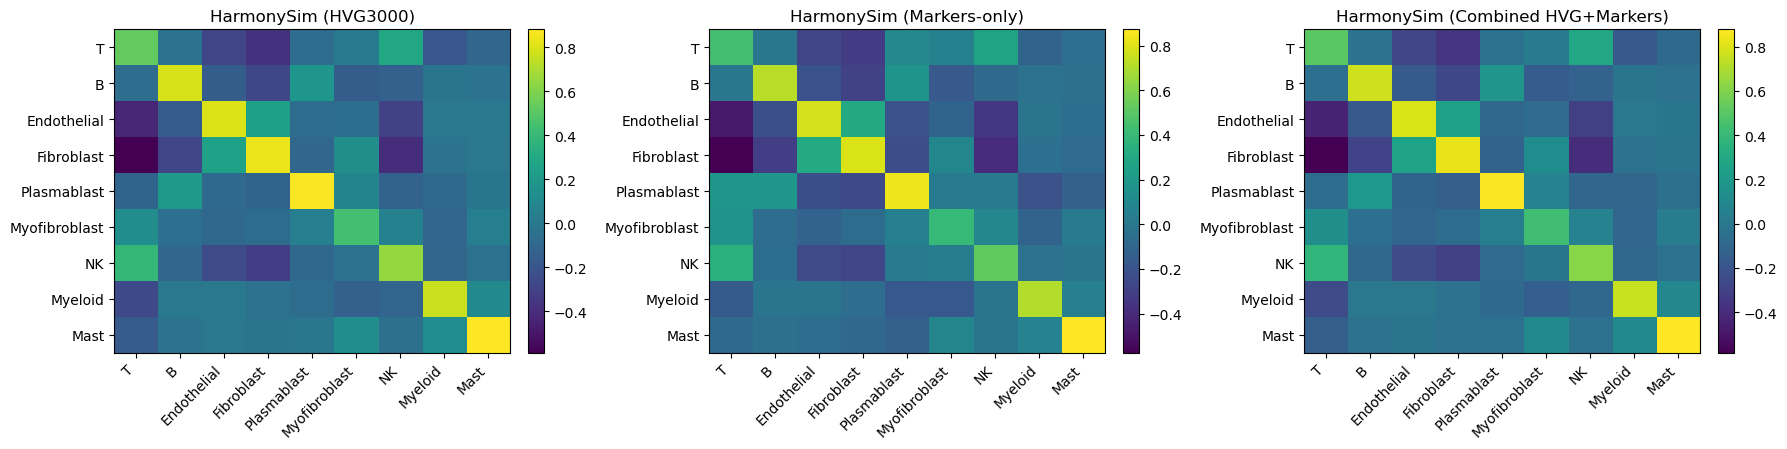

In [27]:
# === Combine HVG-Harmony & Marker-Harmony and compare separation (plot only) ===
import numpy as np
import matplotlib.pyplot as plt

# ---- prerequisites: use what you already have ----
# needs: adata_all, markers_by_ct, LABEL_COL, TARGET_ORDER, BATCH_KEY_ALL, N_PCS
assert "adata_all" in globals() and "markers_by_ct" in globals(), "缺 adata_all 或 markers_by_ct"
assert LABEL_COL in adata_all.obs, f"adata_all.obs 缺少 {LABEL_COL}"
assert "X_pca_harmony" in adata_all.obsm, "請先完成 HVG3000 的 PCA→Harmony（X_pca_harmony）"

def _to_nd(X): return X.A if hasattr(X, "A") else np.asarray(X)

def cosine_sim(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    return A @ B.T

def _safe_union_markers(m_by_ct, var_names):
    return sorted({g for gl in m_by_ct.values() for g in gl if g in var_names})

def _harmony_on_subset(adata, genes, batch_key, n_pcs):
    ad = adata[:, genes].copy()
    sc.pp.scale(ad, max_value=10)
    sc.tl.pca(ad, n_comps=min(n_pcs, ad.n_vars, ad.n_obs), svd_solver="arpack")
    sc.external.pp.harmony_integrate(ad, key=batch_key)  # -> X_pca_harmony
    if "X_pca_harmony" not in ad.obsm:
        raise RuntimeError("Harmony on subset failed.")
    return ad.obsm["X_pca_harmony"]

def _build_harmony_sim(Z, labels, ct_list):
    # centroids
    C, ok = [], []
    for ct in ct_list:
        m = labels == ct
        if m.sum() == 0:
            C.append(np.zeros(Z.shape[1])); ok.append(False)
        else:
            C.append(Z[m].mean(axis=0)); ok.append(True)
    C = np.vstack(C)
    # per-CT平均相似度
    M = np.zeros((len(ct_list), len(ct_list)))
    for i, ct in enumerate(ct_list):
        m = labels == ct
        if m.sum() == 0:
            M[i, :] = np.nan
            continue
        sims = cosine_sim(Z[m], C).mean(axis=0)
        for j, good in enumerate(ok):
            if not good: sims[j] = np.nan
        M[i, :] = sims
    return M

def _sort_rows(cts, target_order):
    order = [ct for ct in target_order if ct in cts]
    rest  = [ct for ct in cts if ct not in order]
    return order + rest

def _sort_cols_by_peak(M, row_cts, col_cts):
    V = M.copy()
    max_idx = np.nanargmax(V, axis=0)
    max_val = np.nanmax(V, axis=0)
    V2 = V.copy()
    for j in range(V2.shape[1]):
        if np.isfinite(V2[max_idx[j], j]):
            V2[max_idx[j], j] = -np.inf
    sec_val = np.nanmax(V2, axis=0)
    margin = max_val - sec_val
    rank = {ct:i for i, ct in enumerate(row_cts)}
    order = sorted(range(len(col_cts)), key=lambda j: (rank[row_cts[max_idx[j]]], -margin[j]))
    return [col_cts[j] for j in order]

def imshow_heatmap(ax, M: np.ndarray, row_labels, col_labels, title: str, vmin=None, vmax=None):
    im = ax.imshow(M, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ---- 1) base labels & CT list ----
labels_ct = adata_all.obs[LABEL_COL].astype(str).values
ct_levels = [ct for ct in TARGET_ORDER if ct in np.unique(labels_ct)]
if not ct_levels:
    ct_levels = sorted(np.unique(labels_ct).tolist())
row_order = _sort_rows(ct_levels, TARGET_ORDER)

# ---- 2) HVG3000-HarmonySim (已有 X_pca_harmony) ----
Z_hvg = adata_all.obsm["X_pca_harmony"]
M_hvg = _build_harmony_sim(Z_hvg, labels_ct, ct_levels)

# ---- 3) Markers-only HarmonySim（若未計算就計算一次）----
union_markers = _safe_union_markers(markers_by_ct, set(adata_all.var_names))
if len(union_markers) < 50:
    raise RuntimeError(f"union markers 太少：{len(union_markers)}。請增大 MARKER_TOPK_CT 或檢查基因交集。")
Z_mark = _harmony_on_subset(adata_all, union_markers, BATCH_KEY_ALL, N_PCS)
M_mark = _build_harmony_sim(Z_mark, labels_ct, ct_levels)

# ---- 4) Combined latent：對兩塊做標準化後 concat，再算 HarmonySim ----
def _stdz(X):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-9
    return (X - mu) / sd
Z_comb = np.concatenate([Z_hvg, Z_mark], axis=1)
# Z_comb = np.concatenate([_stdz(Z_hvg), _stdz(Z_mark)], axis=1)

M_comb = _build_harmony_sim(Z_comb, labels_ct, ct_levels)

# ---- 5) 先用峰值CT+margin排序各矩陣的「欄」；再轉成索引 ----
# 針對「已排序的列(row_order)」取對應的子矩陣，避免行順序不一致
M_hvg_row  = M_hvg[np.ix_([ct_levels.index(ct) for ct in row_order], list(range(len(ct_levels))))]
M_mark_row = M_mark[np.ix_([ct_levels.index(ct) for ct in row_order], list(range(len(ct_levels))))]
M_comb_row = M_comb[np.ix_([ct_levels.index(ct) for ct in row_order], list(range(len(ct_levels))))]

# 依「峰值CT + (max-second) margin」得到欄標籤順序
cols_hvg  = _sort_cols_by_peak(M_hvg_row,  row_order, ct_levels)
cols_mark = _sort_cols_by_peak(M_mark_row, row_order, ct_levels)
cols_comb = _sort_cols_by_peak(M_comb_row, row_order, ct_levels)

# 轉成實際整數索引
rows_order    = [ct_levels.index(ct) for ct in row_order]
cols_hvg_idx  = [ct_levels.index(c) for c in cols_hvg]
cols_mark_idx = [ct_levels.index(c) for c in cols_mark]
cols_comb_idx = [ct_levels.index(c) for c in cols_comb]

# ---- 6) Plot side-by-side（只顯示不存檔）----
plt.figure(figsize=(18, 4.6))

ax1 = plt.subplot(1,3,1)
imshow_heatmap(
    ax1,
    M_hvg[np.ix_(rows_order, cols_hvg_idx)],
    row_order, cols_hvg, "HarmonySim (HVG3000)"
)

ax2 = plt.subplot(1,3,2)
imshow_heatmap(
    ax2,
    M_mark[np.ix_(rows_order, cols_mark_idx)],
    row_order, cols_mark, "HarmonySim (Markers-only)"
)

ax3 = plt.subplot(1,3,3)
imshow_heatmap(
    ax3,
    M_comb[np.ix_(rows_order, cols_comb_idx)],
    row_order, cols_comb, "HarmonySim (Combined HVG+Markers)"
)

plt.tight_layout()
plt.show()



In [34]:
# file: scripts/dump_harmony_latents_to_csv.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd

# ===== Config =====
OUT_DIR = "./outputs_features_csv"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_COL = "highLevelType"          # cell type 欄位名
STANDARDIZE_BEFORE_COMBINE = True    # combined 前各塊 z-score（建議）

# ===== Guards =====
assert "adata_all" in globals(), "需要 adata_all"
assert "X_pca_harmony" in adata_all.obsm, "缺 X_pca_harmony（HVG3000→Harmony）"
assert "markers_by_ct" in globals(), "需要 markers_by_ct 以跑 markers-only Harmony"
assert LABEL_COL in adata_all.obs, f"adata_all.obs 缺少標籤欄位：{LABEL_COL}"

# ===== Meta (cell_type, pct_counts_mt) =====
if "pct_counts_mt" not in adata_all.obs.columns:
    # 若沒算過 QC，就先放 NaN（避免中斷）
    adata_all.obs["pct_counts_mt"] = np.nan

meta = pd.DataFrame({
    "cell_type": adata_all.obs[LABEL_COL].astype(str).values,
    "pct_counts_mt": pd.to_numeric(adata_all.obs["pct_counts_mt"], errors="coerce")
}, index=adata_all.obs_names)

# ===== HVG3000 Harmony latent =====
Z_hvg = adata_all.obsm["X_pca_harmony"]
hvg_cols = [f"harm_{i+1}" for i in range(Z_hvg.shape[1])]
df_hvg = pd.DataFrame(Z_hvg, index=adata_all.obs_names, columns=hvg_cols)
df_hvg = pd.concat([meta, df_hvg], axis=1)
hvg_path = os.path.join(OUT_DIR, "features_hvg_harmony.csv")
df_hvg.to_csv(hvg_path)
print("[OK] wrote:", hvg_path, "| shape:", df_hvg.shape)

# ===== Markers-only Harmony latent =====
# 若上個 cell 已算過 Z_mark 就直接用；否則現算一次
if "Z_mark" not in globals():
    assert "_harmony_on_subset" in globals() and "_safe_union_markers" in globals(), "缺 helper 函式"
    assert "BATCH_KEY_ALL" in globals() and "N_PCS" in globals(), "缺 BATCH_KEY_ALL/N_PCS"
    union_markers = _safe_union_markers(markers_by_ct, set(adata_all.var_names))
    if len(union_markers) < 50:
        raise RuntimeError(f"union markers 太少：{len(union_markers)}")
    Z_mark = _harmony_on_subset(adata_all, union_markers, BATCH_KEY_ALL, N_PCS)

mark_cols = [f"markharm_{i+1}" for i in range(Z_mark.shape[1])]
df_mark = pd.DataFrame(Z_mark, index=adata_all.obs_names, columns=mark_cols)
df_mark = pd.concat([meta, df_mark], axis=1)
mark_path = os.path.join(OUT_DIR, "features_markers_harmony.csv")
df_mark.to_csv(mark_path)
print("[OK] wrote:", mark_path, "| shape:", df_mark.shape)

# ===== Combined latent (raw concat) =====
Z_comb_raw = np.concatenate([Z_hvg, Z_mark], axis=1)
comb_cols = hvg_cols + mark_cols
df_comb_raw = pd.DataFrame(Z_comb_raw, index=adata_all.obs_names, columns=comb_cols)
df_comb_raw = pd.concat([meta, df_comb_raw], axis=1)
comb_path_raw = os.path.join(OUT_DIR, "features_combined.csv")
df_comb_raw.to_csv(comb_path_raw)
print("[OK] wrote:", comb_path_raw, "| shape:", df_comb_raw.shape)

# ===== Combined latent (z-score each block then concat) =====
def _stdz(X: np.ndarray) -> np.ndarray:
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-9
    return (X - mu) / sd

Z_hvg_use  = _stdz(Z_hvg) if STANDARDIZE_BEFORE_COMBINE else Z_hvg
Z_mark_use = _stdz(Z_mark) if STANDARDIZE_BEFORE_COMBINE else Z_mark

Z_comb = np.concatenate([Z_hvg_use, Z_mark_use], axis=1)
df_comb = pd.DataFrame(Z_comb, index=adata_all.obs_names, columns=comb_cols)
df_comb = pd.concat([meta, df_comb], axis=1)
comb_path = os.path.join(OUT_DIR, "features_combined_z-score.csv")
df_comb.to_csv(comb_path)
print("[OK] wrote:", comb_path, "| shape:", df_comb.shape)


[OK] wrote: ./outputs_features_csv\features_hvg_harmony.csv | shape: (50990, 52)
[OK] wrote: ./outputs_features_csv\features_markers_harmony.csv | shape: (50990, 52)
[OK] wrote: ./outputs_features_csv\features_combined.csv | shape: (50990, 102)
[OK] wrote: ./outputs_features_csv\features_combined_z-score.csv | shape: (50990, 102)


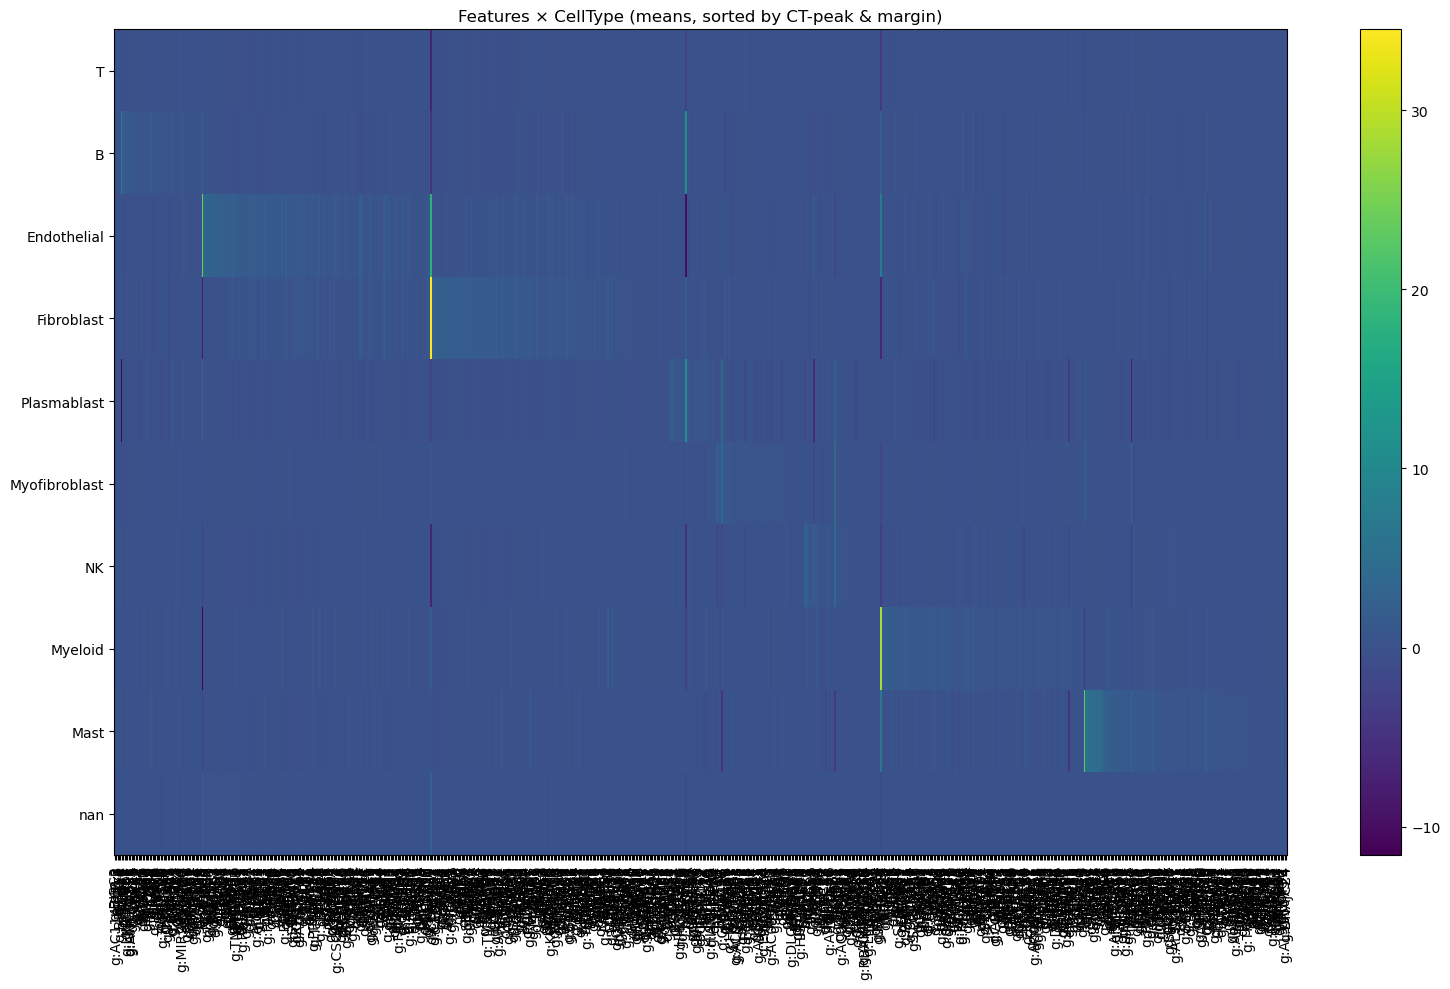

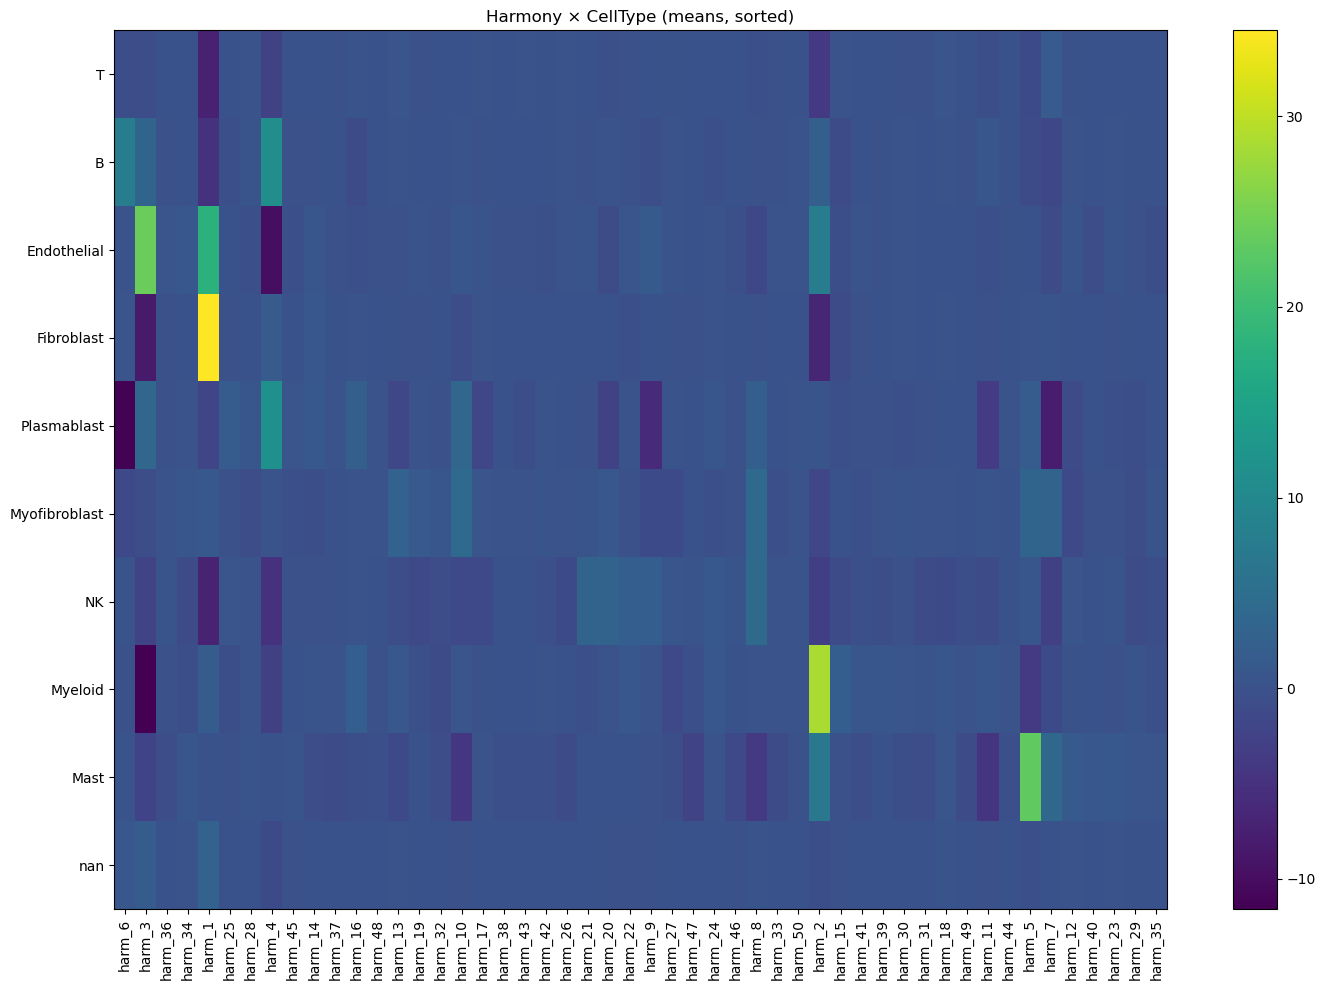

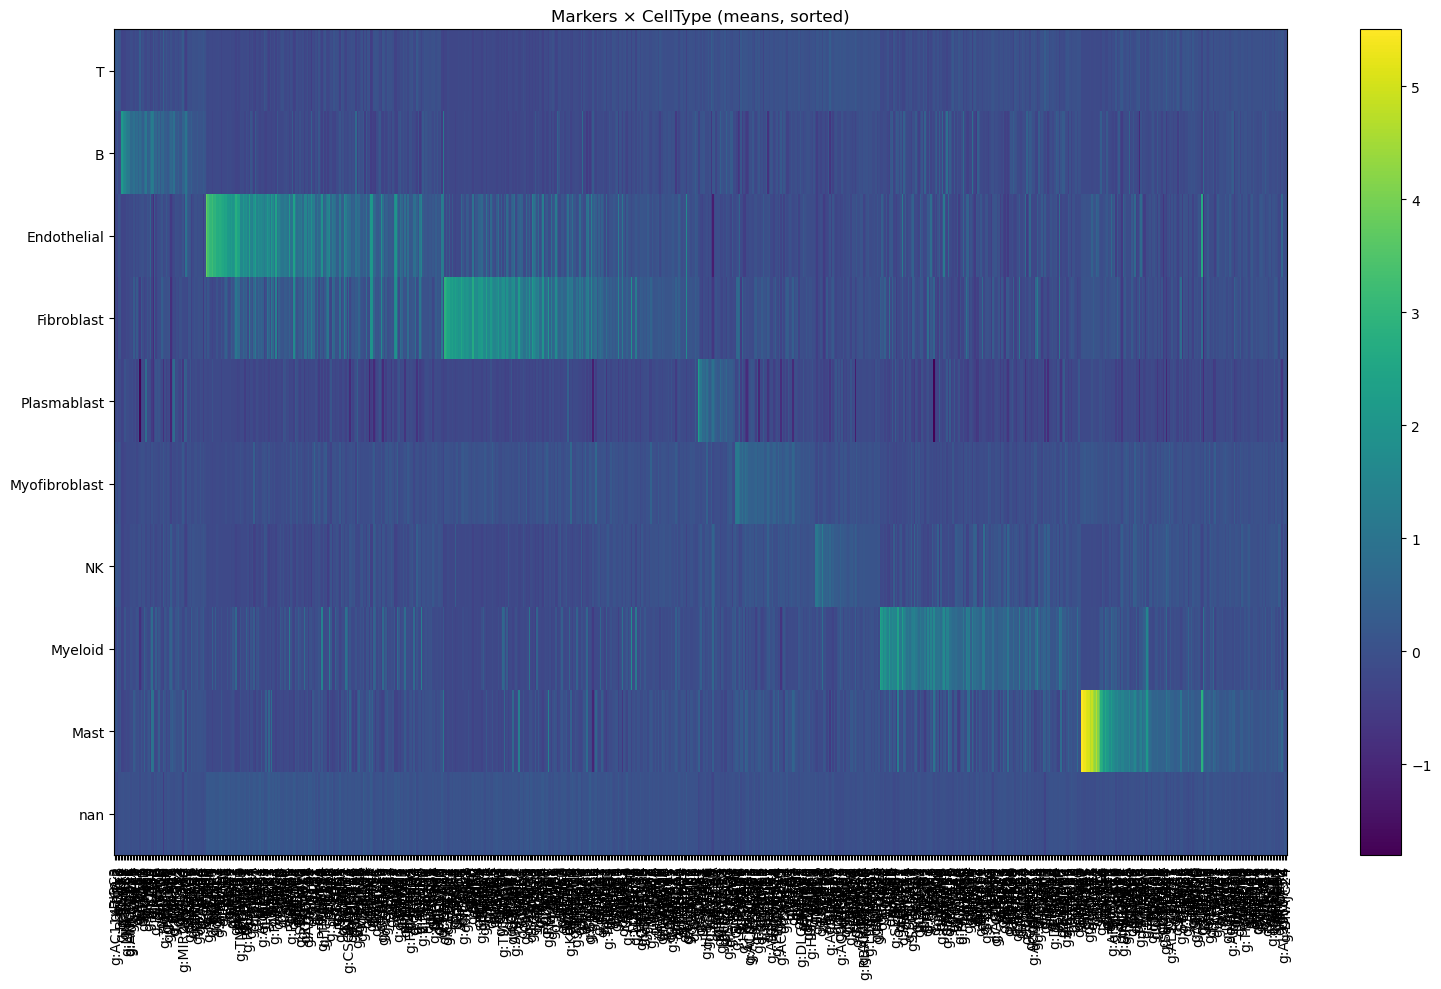

In [20]:
# === Sorted Feature × CellType heatmaps (plot only) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_COL = "highLevelType"  # 你的 cell type 欄位

# ---- guards ----
if "adata_all" not in globals():
    raise RuntimeError("需要先建立 adata_all（含 X_pca_harmony 或 markers）。")
if LABEL_COL not in adata_all.obs:
    raise RuntimeError(f"adata_all.obs 缺少標籤欄位：{LABEL_COL}")

# ---- collect features ----
def _to_nd(X): return X.A if hasattr(X, "A") else np.asarray(X)

# Harmony
X_harm, harm_names = None, []
if "X_pca_harmony" in adata_all.obsm:
    X_harm = adata_all.obsm["X_pca_harmony"]
    harm_names = [f"harm_{i+1}" for i in range(X_harm.shape[1])]

# Markers: 優先 score_；否則 union_markers/markers_by_ct 的 log-normalized 表達
X_mark, marker_names = None, []
score_cols = [c for c in adata_all.obs.columns if str(c).startswith("score_")]
if score_cols:
    X_mark = adata_all.obs[score_cols].to_numpy()
    marker_names = score_cols
else:
    union = None
    if "union_markers" in globals() and isinstance(union_markers, (list, tuple)):
        union = [g for g in union_markers if g in adata_all.var_names]
    elif "markers_by_ct" in globals() and isinstance(markers_by_ct, dict):
        union = sorted({g for gl in markers_by_ct.values() for g in gl if g in adata_all.var_names})
    else:
        union = []
    if union:
        X_mark = _to_nd(adata_all[:, union].X)
        marker_names = [f"g:{g}" for g in union]

blocks, names = [], []
if X_harm is not None:
    blocks.append(X_harm); names.extend(harm_names)
if X_mark is not None:
    blocks.append(X_mark); names.extend(marker_names)
if not blocks:
    raise RuntimeError("沒有可用的 features：無 X_pca_harmony，且無 score_* 或 marker 表達。")

X_all = np.concatenate(blocks, axis=1)
df_feat = pd.DataFrame(X_all, index=adata_all.obs_names, columns=names)

# ---- aggregate to CT means ----
labels = adata_all.obs[LABEL_COL].astype(str)
M_all = df_feat.groupby(labels).mean()       # (CT × features)

# ---- sorting helpers ----
def sort_rows(M: pd.DataFrame) -> list:
    """why: 先用 TARGET_ORDER；否則嘗試階層分群；再不行用原順序。"""
    if "TARGET_ORDER" in globals() and isinstance(TARGET_ORDER, (list, tuple)):
        order = [ct for ct in TARGET_ORDER if ct in M.index]
        rest  = [ct for ct in M.index if ct not in order]
        return order + rest
    try:
        from scipy.cluster.hierarchy import linkage, leaves_list
        Z = linkage(M.values, method="average", metric="euclidean")
        leaf = leaves_list(Z)
        return [M.index[i] for i in leaf]
    except Exception:
        return list(M.index)

def sort_features_by_ct_peak(M: pd.DataFrame, ct_order: list | None) -> list:
    """why: 以『峰值 CT』分組，組內按『max−second』降序，讓區分度強的特徵靠前。"""
    V = M.values  # rows=CT, cols=features
    max_idx = V.argmax(axis=0)
    max_val = V.max(axis=0)
    # 第二大值：用 partial sort 避免排序全列
    sec_val = np.partition(V, -2, axis=0)[-2, :]
    margin = max_val - sec_val
    peak_ct = [M.index[i] for i in max_idx]
    meta = pd.DataFrame({"feature": M.columns, "peak_ct": peak_ct, "margin": margin})

    if ct_order is None:
        ct_order = list(M.index)
    rank = {ct:i for i, ct in enumerate(ct_order)}
    meta["ct_rank"] = meta["peak_ct"].map(rank).fillna(len(rank)).astype(int)

    meta = meta.sort_values(["ct_rank", "margin"], ascending=[True, False])
    return meta["feature"].tolist()

def plot_heatmap(M: pd.DataFrame, title: str):
    plt.figure(figsize=(min(16, 2 + 0.25*len(M.columns)), 0.8*len(M.index) + 2))
    im = plt.imshow(M.values, aspect="auto", interpolation="nearest")
    plt.xticks(range(M.shape[1]), M.columns, rotation=90)
    plt.yticks(range(M.shape[0]), M.index)
    plt.title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

# ---- row/column orders ----
rows_order = sort_rows(M_all)
ct_order   = rows_order  # 用於特徵分組時的 CT 序
# All features
cols_all_sorted = sort_features_by_ct_peak(M_all.loc[rows_order], ct_order)
plot_heatmap(M_all.loc[rows_order, cols_all_sorted], "Features × CellType (means, sorted by CT-peak & margin)")

# Harmony-only
cols_h = [c for c in M_all.columns if c.startswith("harm_")]
if cols_h:
    Mh = M_all[cols_h].loc[rows_order]
    cols_h_sorted = sort_features_by_ct_peak(Mh, ct_order)
    plot_heatmap(Mh.loc[:, cols_h_sorted], "Harmony × CellType (means, sorted)")

# Marker-only
cols_m = [c for c in M_all.columns if c.startswith("score_") or c.startswith("g:")]
if cols_m:
    Mm = M_all[cols_m].loc[rows_order]
    cols_m_sorted = sort_features_by_ct_peak(Mm, ct_order)
    plot_heatmap(Mm.loc[:, cols_m_sorted], "Markers × CellType (means, sorted)")


In [ ]:
ad_.obsm["X_pca_harmony"]

NameError: name 'adata' is not defined

In [22]:
# === LGBM cell-type prediction (ARI / V / 0.5*(ARI+V)) on different feature sets ===
import numpy as np
import pandas as pd
import lightgbm as lgb
from typing import Tuple, Dict
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, v_measure_score

# ---------------- Config ----------------
LABEL_COL      = "highLevelType"     # 真實 cell type 標籤（存在於 Train）
PATIENT_COL    = "Patient"           # 若無，會退回 SAMPLE_COL，再退回無群組
SAMPLE_COL     = "Sample"
SET_COL        = "set"               # 'train' / 'test'（無標籤的通常是 test）
N_SPLITS       = 5
RANDOM_STATE   = 42

LGB_PARAMS = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,           # 交給 early stopping 控制
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
EARLY_STOP_ROUNDS = 50

# ---------------- Guards ----------------
if "adata_all" not in globals():
    raise RuntimeError("需要先建立 adata_all（含 Harmony 或 markers 特徵來源）。")
if LABEL_COL not in adata_all.obs:
    raise RuntimeError(f"adata_all.obs 缺少標籤欄位：{LABEL_COL}")
if SET_COL not in adata_all.obs:
    raise RuntimeError(f"adata_all.obs 需包含分集合併欄位 '{SET_COL}'（train/test）。")

# ---------------- Feature collectors ----------------
def _to_nd(X):
    return X.A if hasattr(X, "A") else np.asarray(X)

def collect_harmony(adata) -> Tuple[np.ndarray, list]:
    if "X_pca_harmony" not in adata.obsm:
        return None, []
    Xh = adata.obsm["X_pca_harmony"]
    names = [f"harm_{i+1}" for i in range(Xh.shape[1])]
    return Xh, names

def collect_markers(adata) -> Tuple[np.ndarray, list]:
    # 1) prefer score_* already computed
    score_cols = [c for c in adata.obs.columns if str(c).startswith("score_")]
    if score_cols:
        Xm = adata.obs[score_cols].to_numpy()
        return Xm, score_cols
    # 2) fallback to union marker genes expression (normalized+log)
    if "union_markers" in globals() and isinstance(union_markers, (list, tuple)):
        genes = [g for g in union_markers if g in adata.var_names]
    elif "markers_by_ct" in globals() and isinstance(markers_by_ct, dict):
        genes = sorted({g for gl in markers_by_ct.values() for g in gl if g in adata.var_names})
    else:
        genes = []
    if not genes:
        return None, []
    Xg = _to_nd(adata[:, genes].X)  # 已 normalize+log1p
    names = [f"g:{g}" for g in genes]
    return Xg, names

# ---------------- Build feature sets ----------------
Xh, names_h = collect_harmony(adata_all)
Xm, names_m = collect_markers(adata_all)

feature_sets: Dict[str, Tuple[np.ndarray, list]] = {}
if Xh is not None:
    feature_sets["Harmony-only"] = (Xh, names_h)
if Xm is not None:
    feature_sets["Marker-only"] = (Xm, names_m)
if Xh is not None and Xm is not None:
    feature_sets["All (Harmony+Markers)"] = (np.concatenate([Xh, Xm], axis=1), names_h + names_m)

if not feature_sets:
    raise RuntimeError("沒有可用的特徵：缺 X_pca_harmony，且無 score_* 或 marker 表達。")

# ---------------- Prepare train data (cells with labels) ----------------
mask_train = (adata_all.obs[SET_COL].astype(str) == "train").values
y_str = adata_all.obs.loc[mask_train, LABEL_COL].astype(str).values
le = LabelEncoder().fit(y_str)
y = le.transform(y_str)

# Groups for CV
if PATIENT_COL in adata_all.obs:
    groups = adata_all.obs.loc[mask_train, PATIENT_COL].astype(str).values
elif SAMPLE_COL in adata_all.obs:
    groups = adata_all.obs.loc[mask_train, SAMPLE_COL].astype(str).values
else:
    groups = None

def do_cv_eval(X_all: np.ndarray, y: np.ndarray, groups) -> pd.DataFrame:
    rows = []
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X_all[mask_train], y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        split_iter = splitter.split(X_all[mask_train], y)
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X_all[mask_train][tr_idx], X_all[mask_train][va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        clf = lgb.LGBMClassifier(num_class=len(le.classes_), **LGB_PARAMS)
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it = clf.best_iteration_ or LGB_PARAMS["n_estimators"]
        y_hat = clf.predict(X_va, num_iteration=best_it)
        ari = adjusted_rand_score(y_va, y_hat)
        v   = v_measure_score(y_va, y_hat)
        combo = 0.5*(ari + v)
        rows.append({"fold": fold, "best_iter": int(best_it), "ARI": float(ari), "V": float(v), "Score": float(combo)})
    df = pd.DataFrame(rows)
    df.loc["mean"] = {"fold": "mean",
                      "best_iter": int(np.round(df["best_iter"].mean())),
                      "ARI": df["ARI"].mean(),
                      "V": df["V"].mean(),
                      "Score": df["Score"].mean()}
    return df

# ---------------- Run & report ----------------
for name, (X, cols) in feature_sets.items():
    print(f"\n=== LGBM CV — {name} ===")
    df = do_cv_eval(X, y, groups)
    print(df.to_string(index=False))



=== LGBM CV — Harmony-only ===
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 22149, number of used features: 50
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.446509
[LightGBM] [Info] Start training from score -5.390427
[LightGBM] [Info] Start training from score -2.311610
[LightGBM] [Info] Start training from score -3.047099
[LightGBM] [Info] Start training from score -3.020831
[LightGBM] [Info] Start training from scor